# No Man's Sky.
https://store.steampowered.com/app/275850/No_Mans_Sky/

### Background

<b>No Man's Sky</b> has probably the greatest comeback story in video game history. The game's [pre-launch hype was so immense](https://techarx.com/26-minutes-no-mans-sky-gameplay-leaked/) that when it was [released](https://gamerant.com/no-mans-sky-second-best-ps4-launch/) and fell far from expectations, <b>Hello Games</b>, the company behind <b>No Man's Sky</b>, was [mercilessly](https://www.vice.com/en/article/inside-the-nasty-no-mans-sky-backlash/) and [viciously](https://www.polygon.com/2016/9/16/12929618/no-mans-sky-disaster-lies-lessons-learned/) dragged through all of social media. One of the biggest complaints was the [lack of multiplayer](https://gearnuke.com/no-mans-sky-multiplayer-no-visible-players/), which was promised in a previous interview, and that set the perception that <b>Hello Games</b> lied to have their broken game sold at all and any cost.

And how did <b>Hello Games</b> respond to such fierce backlash? [Silence](https://www.extremetech.com/gaming/236216-no-ones-playing-no-mans-sky-as-developer-remains-silent-and-players-flee-the-franchise). At first. Rather than pick fights with the media and/or gamers, they initially did not respond and went back to work to get the game patched. For the next year, they released three patches (<i>Foundation</i>, <i>Pathfinder</i>, and <i>Atlas Rises</i>) that made the game much more playable and endeared <b>Hello Games</b> a bit more to the gaming community.

But that was not close to the end of it.

Despite being a small and independent developing and publishing team, <b>Hello Games</b> continued to patch the game and added new features without extra costs to the gamers, something in complete opposite of the larger gaming companies today. Their promised multiplayer feature finally became a reality with the <i>Beyond</i> patch, and the game also got a VR-mode with the <i>Next Generation</i> patch.

After nearly 10 years, <b>Hello Games</b> is still working on <b>No Man's Sky</b>. As of early April 2026, there have been 35 patches with the most recent one only slightly over a month ago, and it does not look like the updates are going to slow down anytime soon either. These efforts have been well received by the gaming community, and <b>No Man's Sky</b>'s overall rating on Steam has shown. Back in late 2021, <b>No Man's Sky</b> finally earned its positive overall rating on Steam. Three years later, <b>No Man's Sky</b> bumped up their positive overall rating to very positive overall rating.

So now... let's look at <b>No Man's Sky</b> through its Steam data and reviews over the years. We will focus only on English ratings and reviews through some of the most important and defining patches.

In [1]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

In [2]:
df = pd.read_json("./mns-data/nms_data.json")

<ipython-input-2-e78768e5b986>:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df = pd.read_json("./mns-data/nms_data.json")
<ipython-input-2-e78768e5b986>:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df = pd.read_json("./mns-data/nms_data.json")
<ipython-input-2-e78768e5b986>:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To

In [3]:
maindata = df[:224134]
metadata = df[224134:]
metadata

,reviews,query_summary,cursors
num_reviews,NaN,100,NaN
review_score,NaN,8,NaN
review_score_desc,NaN,Very Positive,NaN
total_positive,NaN,185715,NaN
total_negative,NaN,38408,NaN
total_reviews,NaN,224123,NaN
AoJ4r/zuv9YCccfjXg==,NaN,NaN,Fri Feb 6 19:40:24 2026


In [4]:
review_score_desc = metadata['query_summary'][2]
total_positive = metadata['query_summary'][3]
total_negative = metadata['query_summary'][4]
total = metadata['query_summary'][5]
pull_date = metadata['cursors'][6]

print(f'Data pulled: {pull_date}')
print(f'Score: {review_score_desc}')
print(f'Total reviews: {total}')
print(f'Positive reviews: {total_positive}')
print(f'Negative reviews: {total_negative}')
print(f'Rating: {round(total_positive*100/total, 2)}%.')

Data pulled: Fri Feb  6 19:40:24 2026
Score: Very Positive
Total reviews: 224123
Positive reviews: 185715
Negative reviews: 38408
Rating: 82.86%.


We need to transform our json data into a dataframe. Let's start by creating a new dataframe with the <b>id</b> column from the reviewers' data.

In [5]:
id_data = [maindata['reviews'][i]['recommendationid'] for i in range(len(maindata))]
mnsdata = pd.DataFrame(id_data, columns = ['id'])
mnsdata

,id
0,217728631
1,217727342
2,217722483
3,217717010
4,217705729
...,...
224129,24845464
224130,24845460
224131,24845437
224132,24845428


We need to add the three following columns to the dataframe from the reviewers' data: <b>Funny</b>, <b>Up</b>, and <b>Total Reviews</b>.

In [6]:
funnies = [maindata['reviews'][i]['votes_funny'] if maindata['reviews'][i]['votes_funny'] != 4294967295 else -1 for i in range(len(maindata))]
upvotes = [maindata['reviews'][i]['votes_up'] for i in range(len(maindata))]
reviews_number_data = [maindata['reviews'][i]['author']['num_reviews'] for i in range(len(maindata))]

mnsdata['Funny'] = funnies
mnsdata['Up'] = upvotes
mnsdata['Total Reviews'] = reviews_number_data

mnsdata

,id,Funny,Up,Total Reviews
0,217728631,0,0,4
1,217727342,0,0,290
2,217722483,0,0,17
3,217717010,0,0,4
4,217705729,0,0,15
...,...,...,...,...
224129,24845464,4,1,90
224130,24845460,0,0,6
224131,24845437,17,31,14
224132,24845428,0,0,16


We also need to add seven more columns to the dataframe: <b>Review Playing Time</b>, <b>Total Playing Time</b>, <b>Post Review Playing Time</b>, <b>Reactions</b>, <b>Reviews</b>, <b>Recommended?</b>, and <b>Steam Purchase</b>.

And just in case <b>Review Playing Time</b> has errors, we will do some error handling. For every error we run into, we will set the value to zero.

In [7]:
review_time_data = []
for i in range(len(maindata)):
    try:
        review_time_data.append(maindata['reviews'][i]['author']['playtime_at_review'])
    except:
        review_time_data.append(0)

In [8]:
total_time_data = [maindata['reviews'][i]['author']['playtime_forever'] for i in range(len(maindata))]
reviews_data = [maindata['reviews'][i]['review'] for i in range(len(maindata))]
review_votes = [maindata['reviews'][i]['voted_up'] for i in range(len(maindata))]
steam_purchase = [maindata['reviews'][i]['steam_purchase'] for i in range(len(maindata))]

mnsdata['Review Playing Time'] = review_time_data
mnsdata['Total Playing Time'] = total_time_data
mnsdata['Post Review Playing Time'] = mnsdata['Total Playing Time'] - mnsdata['Review Playing Time']
mnsdata['Reactions'] = mnsdata['Funny'] + mnsdata['Up']
mnsdata['Reviews'] = reviews_data
mnsdata['Recommended?'] = review_votes
mnsdata['Steam Purchase'] = steam_purchase

mnsdata

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase
0,217728631,0,0,4,275,275,0,0,good sifi game,True,False
1,217727342,0,0,290,246,246,0,0,No man's sky\nIt's an alright game multiplayer...,False,True
2,217722483,0,0,17,11628,11628,0,0,See the universe they said! See the wonders!\r...,True,False
3,217717010,0,0,4,1386,1386,0,0,yes very good,True,True
4,217705729,0,0,15,2858,2979,121,0,"Not just good, super good!",True,True
...,...,...,...,...,...,...,...,...,...,...,...
224129,24845464,4,1,90,1026,1497,471,5,"Quite nice, actually.",True,True
224130,24845460,0,0,6,1856,2425,569,0,Rest in peace Harambe. Your name will always b...,True,True
224131,24845437,17,31,14,1155,3660,2505,48,"1ST PUBLIC REVIEW!\n\nEDIT: Quick tips, left c...",True,True
224132,24845428,0,0,16,1198,4545,3347,0,Its pretty good tbh\nEDIT: Its pretty good but...,False,True


We still need the columns related to time and date: <b>Date</b> and <b>Anniversary</b>.

In [9]:
timestamp = [maindata['reviews'][i]['timestamp_updated'] for i in range(len(maindata))]
date = [datetime.fromtimestamp(timestamp[i]).strftime('%Y-%m-%d') for i in range(len(timestamp))]

mnsdata['Date'] = date
mnsdata

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase,Date
0,217728631,0,0,4,275,275,0,0,good sifi game,True,False,2026-02-06
1,217727342,0,0,290,246,246,0,0,No man's sky\nIt's an alright game multiplayer...,False,True,2026-02-06
2,217722483,0,0,17,11628,11628,0,0,See the universe they said! See the wonders!\r...,True,False,2026-02-06
3,217717010,0,0,4,1386,1386,0,0,yes very good,True,True,2026-02-06
4,217705729,0,0,15,2858,2979,121,0,"Not just good, super good!",True,True,2026-02-06
...,...,...,...,...,...,...,...,...,...,...,...,...
224129,24845464,4,1,90,1026,1497,471,5,"Quite nice, actually.",True,True,2016-08-13
224130,24845460,0,0,6,1856,2425,569,0,Rest in peace Harambe. Your name will always b...,True,True,2018-07-25
224131,24845437,17,31,14,1155,3660,2505,48,"1ST PUBLIC REVIEW!\n\nEDIT: Quick tips, left c...",True,True,2016-08-12
224132,24845428,0,0,16,1198,4545,3347,0,Its pretty good tbh\nEDIT: Its pretty good but...,False,True,2016-08-17


In [10]:
for i in range(1, 11):
    mnsdata.loc[(mnsdata['Date'] >= f'{2015+i}-08-12') & (mnsdata['Date'] < f'{2016+i}-08-12'), ['Anniversary']] = i

mnsdata['Anniversary'] = mnsdata['Anniversary'].astype('int')
mnsdata

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase,Date,Anniversary
0,217728631,0,0,4,275,275,0,0,good sifi game,True,False,2026-02-06,10
1,217727342,0,0,290,246,246,0,0,No man's sky\nIt's an alright game multiplayer...,False,True,2026-02-06,10
2,217722483,0,0,17,11628,11628,0,0,See the universe they said! See the wonders!\r...,True,False,2026-02-06,10
3,217717010,0,0,4,1386,1386,0,0,yes very good,True,True,2026-02-06,10
4,217705729,0,0,15,2858,2979,121,0,"Not just good, super good!",True,True,2026-02-06,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
224129,24845464,4,1,90,1026,1497,471,5,"Quite nice, actually.",True,True,2016-08-13,1
224130,24845460,0,0,6,1856,2425,569,0,Rest in peace Harambe. Your name will always b...,True,True,2018-07-25,2
224131,24845437,17,31,14,1155,3660,2505,48,"1ST PUBLIC REVIEW!\n\nEDIT: Quick tips, left c...",True,True,2016-08-12,1
224132,24845428,0,0,16,1198,4545,3347,0,Its pretty good tbh\nEDIT: Its pretty good but...,False,True,2016-08-17,1


Because we will only be covering <b>No Man's Sky</b> from its launch all the way up to its very positive overall rating on Steam, we are going to split the dataframe into two: <b>pre-positive</b> and <b>post-positive</b> (and leave everything else aside).

In [11]:
mnsdata_pre_positive = mnsdata.loc[(mnsdata['Date'] < '2021-09-07')]
mnsdata_pre_positive

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase,Date,Anniversary
100690,98919984,1,1,1,484,3138,2654,2,Literally the best game ever made.,True,True,2021-09-06,6
100691,98919825,0,0,2,12145,12145,0,0,***Ultimate Come Back Game in the Game History...,True,True,2021-09-06,6
100692,98919782,0,0,12,6869,12788,5919,0,I was one of them Pre order OGs who were let d...,True,True,2021-09-06,6
100693,98919715,0,0,1,2978,3206,228,0,Awesome game getting better with game updates,True,True,2021-09-06,6
100694,98919665,0,0,3,32770,62471,29701,0,I started my No Man's Sky travels around the B...,True,False,2021-09-06,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
224129,24845464,4,1,90,1026,1497,471,5,"Quite nice, actually.",True,True,2016-08-13,1
224130,24845460,0,0,6,1856,2425,569,0,Rest in peace Harambe. Your name will always b...,True,True,2018-07-25,2
224131,24845437,17,31,14,1155,3660,2505,48,"1ST PUBLIC REVIEW!\n\nEDIT: Quick tips, left c...",True,True,2016-08-12,1
224132,24845428,0,0,16,1198,4545,3347,0,Its pretty good tbh\nEDIT: Its pretty good but...,False,True,2016-08-17,1


In [12]:
mnsdata_post_positive = mnsdata.loc[(mnsdata['Date'] > '2021-09-06') & (mnsdata['Date'] < '2024-11-28')]
mnsdata_post_positive

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase,Date,Anniversary
34999,180266871,0,0,13,13191,13219,28,0,The fact that the developers still support thi...,True,True,2024-11-27,9
35001,180264657,1,2,1,19042,19048,6,3,\r\nNo Mans Sky generated great excitement whe...,True,True,2024-11-27,9
35002,180263674,0,1,6,68381,75724,7343,1,I approve.,True,True,2024-11-27,9
35003,180263268,0,0,32,2438,8264,5826,0,Fun exploration and space management game. I w...,True,True,2024-11-27,9
35004,180262901,0,0,5,5052,7061,2009,0,The game used to be not so great and pretty bu...,True,True,2024-11-27,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
224013,24846167,0,0,12,818,16450,15632,0,The game has come such a long way since its in...,True,True,2024-05-25,8
224029,24846075,0,0,1,30,1978,1948,0,game good now\n\n\n\n,True,True,2022-01-23,6
224039,24846032,0,0,5,82,5908,5826,0,Frame rate issues as soon a I start the game. ...,True,True,2022-07-17,6
224058,24845916,0,0,16,11,6667,6656,0,greatest gaming comeback ever,True,True,2022-04-23,6


That should do it! Let's go over how <b>No Man's Sky</b> has evolved over the (almost) last 10 years.

### Part I: Overview.

#### Which No Man's Sky review garnered the most reactions?

In [13]:
pre_positive_upvoted_count = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] == max(mnsdata_pre_positive['Reactions']))]['Reactions'].values[0]
pre_positive_upvoted_review = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] == max(mnsdata_pre_positive['Reactions']))]['Reviews'].values[0]
pre_positive_upvoted_funny = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] == max(mnsdata_pre_positive['Reactions']))]['Funny'].values[0]
pre_positive_upvoted_upvote = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] == max(mnsdata_pre_positive['Reactions']))]['Up'].values[0]
pre_positive_upvoted_date = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] == max(mnsdata_pre_positive['Reactions']))]['Date'].values[0]

print(f'{pre_positive_upvoted_review}')
print(f'---\nSubmitted on {pre_positive_upvoted_date}, this review garnered {pre_positive_upvoted_count} reactions ({pre_positive_upvoted_funny} laughs and {pre_positive_upvoted_upvote} upvotes).')

This game has endless possiblities. 
[spoiler]Almost all of which are not featured in this game. [/spoiler]
I had a great time playing this game.
[spoiler]For the first 8 hours and then it was just a grind. [/spoiler]
I just couldn't stop playing it.
[spoiler] Mostly because I hoped for something awesome at the center.[/spoiler]
[spoiler] But there is [b]literally nothing[/b] at the center.[/spoiler] 
[spoiler] It actually takes things away from you instead.[/spoiler]
I got all the achievements
[spoiler] But, I still don't have all of the blueprints.[/spoiler]
[spoiler] Message Found, Message Already Learned [/spoiler]
This Game is great
[spoiler] at wasting your time.[/spoiler]
18/18[spoiler]quintillion[/spoiler] Would recommend
[spoiler] tossing this game into a blackhole.[/spoiler]
---
Submitted on 2016-08-30, this review garnered 24533 reactions (15726 laughs and 8807 upvotes).


Submitted about two weeks after the game's initial launch, the review was scathing. The reviewer listed out what the reality was compared to its pre-launchg expectation and did so without mincing words. 

With over 24,000 reactions and a roughly 2-to-1 ratio between funny reactions and upvotes, this review captured how the community felt during <b>No Man's Sky</b>'s release.

#### How did the other reviews with over 10,000 reactions feel about the game?

In [14]:
mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] > 10000)].sort_values(by='Reactions', ascending=False)

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase,Date,Anniversary
197071,25085256,15726,8807,1,4506,6826,2320,24533,This game has endless possiblities. \n[spoiler...,False,True,2016-08-30,1
223037,24849441,951,16997,34,1889,1906,17,17948,"Overhyped, poorly optimized, indie game made b...",False,True,2017-11-23,2
223869,24846676,12557,4762,37,27,27,0,17319,The refund button works well.,True,True,2016-08-12,1
223892,24846605,11481,4755,124,1534,3553,2019,16236,No Man's PC can handle it.,False,True,2017-07-19,1
193335,25192968,10875,4556,13,42,652,610,15431,I overpaid.,False,False,2016-08-27,1
205238,24937494,2487,12327,9,226,1494,1268,14814,A mile wide but an inch deep. I can not expres...,False,True,2016-08-15,1
179907,26423469,7926,5629,5,1132,1132,0,13555,I could have bought 2 bags of weed instead.,False,True,2016-11-04,1
141670,61563075,2595,10120,1,1992,4986,2994,12715,"Thank you internet historian, very cool!",True,True,2020-01-09,4
167037,43719143,233,10935,78,2169,11994,9825,11168,Honestly not a bad game. at launch it was a li...,True,True,2018-07-24,2
224105,24845666,1727,9059,1,35,116,81,10786,Crashes on open every time. gg\n\n\n*For the c...,False,True,2016-08-12,1


While there were only three positive reviews, one of them was definitely being sarcastic because the review was <i>"The refund button works well."</i> after playing only 27 minutes. That means in reality there were only two positive reviews and both of them came at least two years after the game's initial launch. To state the gaming community hated <b>No Man's Sky</b> with a passion is a bit of an understatement.

Fun note? There's a reference to the <b>Internet Historian</b> who did a video over the history of this game as well!

#### How did the reviews break down by reactions?

In [15]:
pre_positive_reactions_over_100 = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] > 100)]
pre_positive_reactions_between_51_and_100 = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] > 50) & (mnsdata_pre_positive['Reactions'] <= 100)]
pre_positive_reactions_between_26_and_50 = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] > 25) & (mnsdata_pre_positive['Reactions'] <= 50)]
pre_positive_reactions_between_11_and_25 = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] > 10) & (mnsdata_pre_positive['Reactions'] <= 25)]
pre_positive_reactions_between_1_and_10 = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] >= 1) & (mnsdata_pre_positive['Reactions'] <= 10)]
pre_positive_reactions_at_0 = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Reactions'] == 0)]

pre_positive_reactions_by_category = [
    pre_positive_reactions_over_100.count()[0],
    pre_positive_reactions_between_51_and_100.count()[0],
    pre_positive_reactions_between_26_and_50.count()[0],
    pre_positive_reactions_between_11_and_25.count()[0],
    pre_positive_reactions_between_1_and_10.count()[0],
    pre_positive_reactions_at_0.count()[0]
]

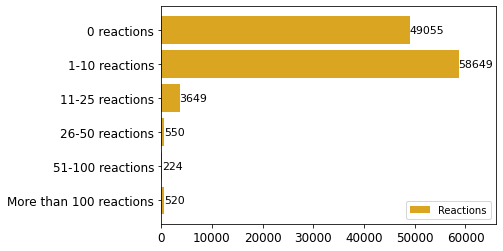

In [16]:
fig, ax = plt.subplots()
reactions_categories = ['More than 100 reactions', '51-100 reactions', '26-50 reactions', '11-25 reactions', '1-10 reactions', '0 reactions']

plt.barh(reactions_categories, pre_positive_reactions_by_category, label='Reactions', color='goldenrod')
plt.xticks(size=12)
plt.xlim(0, 66000)
plt.yticks(rotation='horizontal', size=12)

for index in range(len(reactions_categories)):
    ax.text(pre_positive_reactions_by_category[index], reactions_categories[index], pre_positive_reactions_by_category[index], rotation='horizontal', va='center', size=11)

plt.legend(loc='lower right')

plt.show()

In [17]:
pre_positive_reactions_over_100_positive = pre_positive_reactions_over_100.loc[(mnsdata_pre_positive['Recommended?'] == True)].count()[0]
pre_positive_reactions_over_100_negative = pre_positive_reactions_over_100.loc[(mnsdata_pre_positive['Recommended?'] == False)].count()[0]
pre_positive_reactions_between_51_and_100_positive = pre_positive_reactions_between_51_and_100.loc[(mnsdata_pre_positive['Recommended?'] == True)].count()[0]
pre_positive_reactions_between_51_and_100_negative = pre_positive_reactions_between_51_and_100.loc[(mnsdata_pre_positive['Recommended?'] == False)].count()[0]
pre_positive_reactions_between_26_and_50_positive = pre_positive_reactions_between_26_and_50.loc[(mnsdata_pre_positive['Recommended?'] == True)].count()[0]
pre_positive_reactions_between_26_and_50_negative = pre_positive_reactions_between_26_and_50.loc[(mnsdata_pre_positive['Recommended?'] == False)].count()[0]
pre_positive_reactions_between_11_and_25_positive = pre_positive_reactions_between_11_and_25.loc[(mnsdata_pre_positive['Recommended?'] == True)].count()[0]
pre_positive_reactions_between_11_and_25_negative = pre_positive_reactions_between_11_and_25.loc[(mnsdata_pre_positive['Recommended?'] == False)].count()[0]
pre_positive_reactions_between_1_and_10_positive = pre_positive_reactions_between_1_and_10.loc[(mnsdata_pre_positive['Recommended?'] == True)].count()[0]
pre_positive_reactions_between_1_and_10_negative = pre_positive_reactions_between_1_and_10.loc[(mnsdata_pre_positive['Recommended?'] == False)].count()[0]
pre_positive_reactions_at_0_positive = pre_positive_reactions_at_0.loc[(mnsdata_pre_positive['Recommended?'] == True)].count()[0]
pre_positive_reactions_at_0_negative = pre_positive_reactions_at_0.loc[(mnsdata_pre_positive['Recommended?'] == False)].count()[0]

pre_positive_review_by_reactions_positive = [
    pre_positive_reactions_over_100_positive,
    pre_positive_reactions_between_51_and_100_positive,
    pre_positive_reactions_between_26_and_50_positive,
    pre_positive_reactions_between_11_and_25_positive,
    pre_positive_reactions_between_1_and_10_positive,
    pre_positive_reactions_at_0_positive
]
pre_positive_review_by_reactions_negative = [
    pre_positive_reactions_over_100_negative,
    pre_positive_reactions_between_51_and_100_negative,
    pre_positive_reactions_between_26_and_50_negative,
    pre_positive_reactions_between_11_and_25_negative,
    pre_positive_reactions_between_1_and_10_negative,
    pre_positive_reactions_at_0_negative
]

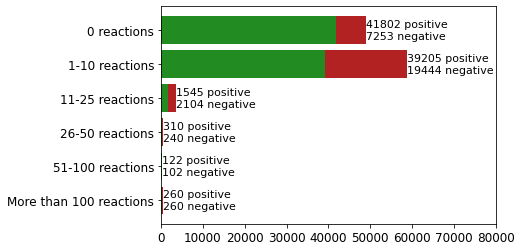

In [18]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, pre_positive_review_by_reactions_positive, color='forestgreen')
plt.barh(reactions_categories, pre_positive_review_by_reactions_negative, left=pre_positive_review_by_reactions_positive, color='firebrick')
plt.xticks(rotation='horizontal', size=12)
plt.xlim(0, 80000)
plt.yticks(size=12)

for index in range(len(reactions_categories)):
    ax.text(pre_positive_review_by_reactions_positive[index]+pre_positive_review_by_reactions_negative[index], reactions_categories[index], f'{pre_positive_review_by_reactions_positive[index]} positive\n{pre_positive_review_by_reactions_negative[index]} negative', ha='left', va='center', size=11)

plt.show()

#### How were the ratings broken down by patches?

In [19]:
initial_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] <= '2016-11-25') & (mnsdata_pre_positive['Recommended?'] == True)]
initial_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] <= '2016-11-25') & (mnsdata_pre_positive['Recommended?'] == False)]
foundation_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2016-11-26') & (mnsdata_pre_positive['Date'] <= '2017-03-07') & (mnsdata_pre_positive['Recommended?'] == True)]
foundation_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2016-11-26') & (mnsdata_pre_positive['Date'] <= '2017-03-07') & (mnsdata_pre_positive['Recommended?'] == False)]
pathfinder_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2017-03-08') & (mnsdata_pre_positive['Date'] <= '2017-08-10') & (mnsdata_pre_positive['Recommended?'] == True)]
pathfinder_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2017-03-08') & (mnsdata_pre_positive['Date'] <= '2017-08-10') & (mnsdata_pre_positive['Recommended?'] == False)]
atlas_rises_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2017-08-11') & (mnsdata_pre_positive['Date'] <= '2018-07-23') & (mnsdata_pre_positive['Recommended?'] == True)]
atlas_rises_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2017-08-11') & (mnsdata_pre_positive['Date'] <= '2018-07-23') & (mnsdata_pre_positive['Recommended?'] == False)]
next_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-07-24') & (mnsdata_pre_positive['Date'] <= '2018-10-28') & (mnsdata_pre_positive['Recommended?'] == True)]
next_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-07-24') & (mnsdata_pre_positive['Date'] <= '2018-10-28') & (mnsdata_pre_positive['Recommended?'] == False)]
abyss_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-10-29') & (mnsdata_pre_positive['Date'] <= '2018-11-21') & (mnsdata_pre_positive['Recommended?'] == True)]
abyss_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-10-29') & (mnsdata_pre_positive['Date'] <= '2018-11-21') & (mnsdata_pre_positive['Recommended?'] == False)]
visions_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-11-22') & (mnsdata_pre_positive['Date'] <= '2019-08-13') & (mnsdata_pre_positive['Recommended?'] == True)]
visions_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-11-22') & (mnsdata_pre_positive['Date'] <= '2019-08-13') & (mnsdata_pre_positive['Recommended?'] == False)]
beyond_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2019-08-14') & (mnsdata_pre_positive['Date'] <= '2019-11-27') & (mnsdata_pre_positive['Recommended?'] == True)]
beyond_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2019-08-14') & (mnsdata_pre_positive['Date'] <= '2019-11-27') & (mnsdata_pre_positive['Recommended?'] == False)]
synthesis_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2019-11-28') & (mnsdata_pre_positive['Date'] <= '2020-02-17') & (mnsdata_pre_positive['Recommended?'] == True)]
synthesis_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2019-11-28') & (mnsdata_pre_positive['Date'] <= '2020-02-17') & (mnsdata_pre_positive['Recommended?'] == False)]
living_ship_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-02-18') & (mnsdata_pre_positive['Date'] <= '2020-04-06') & (mnsdata_pre_positive['Recommended?'] == True)]
living_ship_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-02-18') & (mnsdata_pre_positive['Date'] <= '2020-04-06') & (mnsdata_pre_positive['Recommended?'] == False)]
exo_mech_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-04-07') & (mnsdata_pre_positive['Date'] <= '2020-06-10') & (mnsdata_pre_positive['Recommended?'] == True)]
exo_mech_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-04-07') & (mnsdata_pre_positive['Date'] <= '2020-06-10') & (mnsdata_pre_positive['Recommended?'] == False)]
crossplay_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-06-11') & (mnsdata_pre_positive['Date'] <= '2020-07-15') & (mnsdata_pre_positive['Recommended?'] == True)]
crossplay_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-06-11') & (mnsdata_pre_positive['Date'] <= '2020-07-15') & (mnsdata_pre_positive['Recommended?'] == False)]
desolation_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-07-16') & (mnsdata_pre_positive['Date'] <= '2020-09-22') & (mnsdata_pre_positive['Recommended?'] == True)]
desolation_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-07-16') & (mnsdata_pre_positive['Date'] <= '2020-09-22') & (mnsdata_pre_positive['Recommended?'] == False)]
origins_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-09-23') & (mnsdata_pre_positive['Date'] <= '2020-11-09') & (mnsdata_pre_positive['Recommended?'] == True)]
origins_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-09-23') & (mnsdata_pre_positive['Date'] <= '2020-11-09') & (mnsdata_pre_positive['Recommended?'] == False)]
next_gen_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-11-10') & (mnsdata_pre_positive['Date'] <= '2021-02-16') & (mnsdata_pre_positive['Recommended?'] == True)]
next_gen_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-11-10') & (mnsdata_pre_positive['Date'] <= '2021-02-16') & (mnsdata_pre_positive['Recommended?'] == False)]
companions_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-02-17') & (mnsdata_pre_positive['Date'] <= '2021-03-30') & (mnsdata_pre_positive['Recommended?'] == True)]
companions_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-02-17') & (mnsdata_pre_positive['Date'] <= '2021-03-30') & (mnsdata_pre_positive['Recommended?'] == False)]
expeditions_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-03-31') & (mnsdata_pre_positive['Date'] <= '2021-06-01') & (mnsdata_pre_positive['Recommended?'] == True)]
expeditions_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-03-31') & (mnsdata_pre_positive['Date'] <= '2021-06-01') & (mnsdata_pre_positive['Recommended?'] == False)]
prisms_positives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-06-02') & (mnsdata_pre_positive['Date'] <= '2021-08-30') & (mnsdata_pre_positive['Recommended?'] == True)]
prisms_negatives = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-06-02') & (mnsdata_pre_positive['Date'] <= '2021-08-30') & (mnsdata_pre_positive['Recommended?'] == False)]

pre_positive_patch_pct = [
    initial_positives.count()[0]/(initial_positives.count()[0]+initial_negatives.count()[0]),
    foundation_positives.count()[0]/(foundation_positives.count()[0]+foundation_negatives.count()[0]),
    pathfinder_positives.count()[0]/(pathfinder_positives.count()[0]+pathfinder_negatives.count()[0]),
    atlas_rises_positives.count()[0]/(atlas_rises_positives.count()[0]+atlas_rises_negatives.count()[0]),
    next_positives.count()[0]/(next_positives.count()[0]+next_negatives.count()[0]),
    abyss_positives.count()[0]/(abyss_positives.count()[0]+abyss_negatives.count()[0]),
    visions_positives.count()[0]/(visions_positives.count()[0]+visions_negatives.count()[0]),
    beyond_positives.count()[0]/(beyond_positives.count()[0]+beyond_negatives.count()[0]),
    synthesis_positives.count()[0]/(synthesis_positives.count()[0]+synthesis_negatives.count()[0]),
    living_ship_positives.count()[0]/(living_ship_positives.count()[0]+living_ship_negatives.count()[0]),
    exo_mech_positives.count()[0]/(exo_mech_positives.count()[0]+exo_mech_negatives.count()[0]),
    crossplay_positives.count()[0]/(crossplay_positives.count()[0]+crossplay_negatives.count()[0]),
    desolation_positives.count()[0]/(desolation_positives.count()[0]+desolation_negatives.count()[0]),
    origins_positives.count()[0]/(origins_positives.count()[0]+origins_negatives.count()[0]),
    next_gen_positives.count()[0]/(next_gen_positives.count()[0]+next_gen_negatives.count()[0]),
    companions_positives.count()[0]/(companions_positives.count()[0]+companions_negatives.count()[0]),
    expeditions_positives.count()[0]/(expeditions_positives.count()[0]+expeditions_negatives.count()[0]),
    prisms_positives.count()[0]/(prisms_positives.count()[0]+prisms_negatives.count()[0])
]

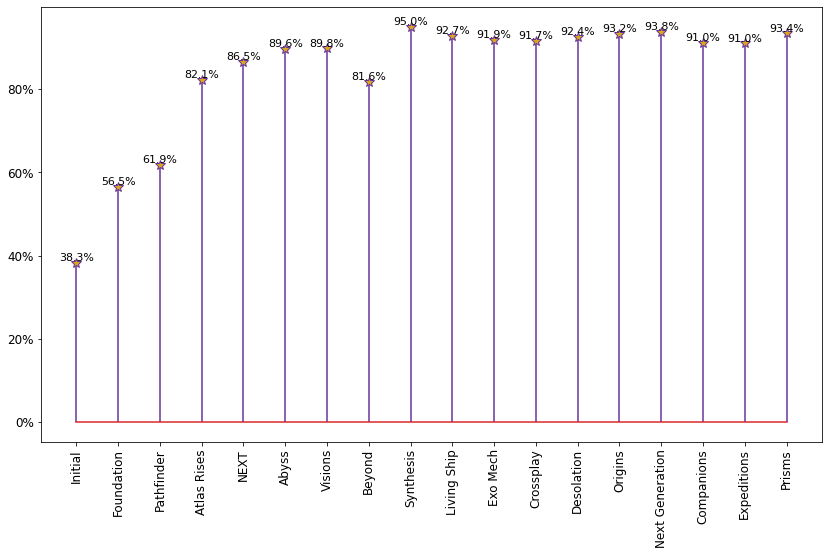

In [20]:
patches = ['Initial', 'Foundation', 'Pathfinder', 'Atlas Rises', 'NEXT', 'Abyss', 'Visions', 'Beyond', 'Synthesis', 'Living Ship', 'Exo Mech', 'Crossplay', 'Desolation', 'Origins', 'Next Generation', 'Companions', 'Expeditions', 'Prisms']

fig, ax = plt.subplots(figsize=(14,8))

markerline, stemlines, baseline=plt.stem(patches, pre_positive_patch_pct, linefmt='rebeccapurple', markerfmt='*')
markerline.set_markerfacecolor('goldenrod')

plt.setp(markerline, markersize=10)
plt.xticks(rotation='vertical', size=12)
plt.yticks(size=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

for index in range(len(patches)):
    ax.text(patches[index], pre_positive_patch_pct[index], f'{round(pre_positive_patch_pct[index]*100, 1)}%', ha='center', va='bottom', size=11)

plt.show()

Three interesting points to mention!
- That near 20% jump from <i>Initial</i> to <i>Foundation</i> showed a willingness from the community to give the game another look after <b>Hello Games</b> made a series of fundamental updates addressing the many issues and complaints raised since launch. 
- That over 20% jump from <i>Pathfinder</i> to <i>Atlas Rises</i> was not a surprise given the complete overhaul the game received as part of its one year anniversary. That overhaul was so immense that even the [gaming press](https://www.gq-magazine.co.uk/article/no-mans-sky-atlas-rises-review) picked up on it and gave the game a positive overview, something the gaming community responded in agreement as well.
- That 8% drop from <i>Visions</i> to <i>Beyond</i>, the only major ratings drop for the game, came from the uneven VR gameplay experiences that were [plagued with flaws and glitches](https://www.gamespot.com/reviews/no-mans-sky-beyond-review-reach-for-the-stars/1900-6417292/).

#### How did its cumulative rating change after each patch release?

In [21]:
initial_total_agg = (initial_positives.count()[0] + initial_negatives.count()[0])
foundation_agg = (initial_positives.count()[0] + foundation_positives.count()[0])
foundation_total_agg = (foundation_positives.count()[0] + foundation_negatives.count()[0] + initial_total_agg)
pathfinder_agg = (pathfinder_positives.count()[0] + foundation_agg)
pathfinder_total_agg = (pathfinder_positives.count()[0] + pathfinder_negatives.count()[0] + foundation_total_agg)
atlas_rises_agg = (atlas_rises_positives.count()[0] + pathfinder_agg)
atlas_rises_total_agg = (atlas_rises_positives.count()[0] + atlas_rises_negatives.count()[0] + pathfinder_total_agg)
next_agg = (next_positives.count()[0] + atlas_rises_agg)
next_total_agg = (next_positives.count()[0] + next_negatives.count()[0] + atlas_rises_total_agg)
abyss_agg = (abyss_positives.count()[0] + next_agg)
abyss_total_agg = (abyss_positives.count()[0] + abyss_negatives.count()[0] + next_total_agg)
visions_agg = (visions_positives.count()[0] + abyss_agg)
visions_total_agg = (visions_positives.count()[0] + visions_negatives.count()[0] + abyss_total_agg)
beyond_agg = (beyond_positives.count()[0] + visions_agg)
beyond_total_agg = (beyond_positives.count()[0] + beyond_negatives.count()[0] + visions_total_agg)
synthesis_agg = (synthesis_positives.count()[0] + beyond_agg)
synthesis_total_agg = (synthesis_positives.count()[0] + synthesis_negatives.count()[0] + beyond_total_agg)
living_ship_agg = (living_ship_positives.count()[0] + synthesis_agg)
living_ship_total_agg = (living_ship_positives.count()[0] + living_ship_negatives.count()[0] + synthesis_total_agg)
exo_mech_agg = (exo_mech_positives.count()[0] + living_ship_agg)
exo_mech_total_agg = (exo_mech_positives.count()[0] + exo_mech_negatives.count()[0] + living_ship_total_agg)
crossplay_agg = (crossplay_positives.count()[0] + exo_mech_agg)
crossplay_total_agg = (crossplay_positives.count()[0] + crossplay_negatives.count()[0] + exo_mech_total_agg)
desolation_agg = (desolation_positives.count()[0] + crossplay_agg)
desolation_total_agg = (desolation_positives.count()[0] + desolation_negatives.count()[0] + crossplay_total_agg)
origins_agg = (origins_positives.count()[0] + desolation_agg)
origins_total_agg = (origins_positives.count()[0] + origins_negatives.count()[0] + desolation_total_agg)
next_gen_agg = (next_gen_positives.count()[0] + origins_agg)
next_gen_total_agg = (next_gen_positives.count()[0] + next_gen_negatives.count()[0] + origins_total_agg)
companions_agg = (companions_positives.count()[0] + next_gen_agg)
companions_total_agg = (companions_positives.count()[0] + companions_negatives.count()[0] + next_gen_total_agg)
expeditions_agg = (expeditions_positives.count()[0] + companions_agg)
expeditions_total_agg = (expeditions_positives.count()[0] + expeditions_negatives.count()[0] + companions_total_agg)
prisms_agg = (prisms_positives.count()[0] + expeditions_agg)
prisms_total_agg = (prisms_positives.count()[0] + prisms_negatives.count()[0] + expeditions_total_agg)

pre_positive_pct_agg = [
    initial_positives.count()[0]/initial_total_agg,
    foundation_agg/foundation_total_agg,
    pathfinder_agg/pathfinder_total_agg,
    atlas_rises_agg/atlas_rises_total_agg,
    next_agg/next_total_agg,
    abyss_agg/abyss_total_agg,
    visions_agg/visions_total_agg,
    beyond_agg/beyond_total_agg,
    synthesis_agg/synthesis_total_agg,
    living_ship_agg/living_ship_total_agg,
    exo_mech_agg/exo_mech_total_agg,
    crossplay_agg/crossplay_total_agg,
    desolation_agg/desolation_total_agg,
    origins_agg/origins_total_agg,
    next_gen_agg/next_gen_total_agg,
    companions_agg/companions_total_agg,
    expeditions_agg/expeditions_total_agg,
    prisms_agg/prisms_total_agg
]

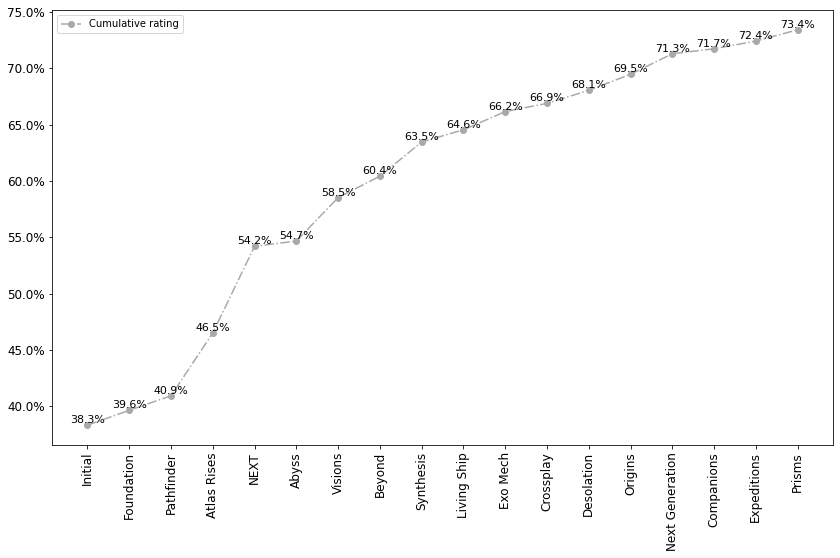

In [22]:
fig, ax = plt.subplots(figsize=(14, 8))

plt.plot(patches, pre_positive_pct_agg, '-.', label='Cumulative rating', color='darkgrey', marker='o')
plt.xticks(rotation='vertical', size=12)
plt.yticks(size=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

for index in range(len(patches)):
    ax.text(patches[index], pre_positive_pct_agg[index], f'{round(pre_positive_pct_agg[index]*100, 1)}%', ha='center', va='bottom', size=11)

plt.legend()

plt.show()

That run from <i>Pathfinder</i> to <i>Atlas Rises</i> to <i>NEXT</i> to <i>Abyss</i> to <i>Visions</i> was the biggest jump <b>No Man's Sky</b> has ever had, and it clocked in at <b>+17.6%</b>. <i>Abyss</i> may look like it is out of place because it barely moved the needle, but that patch only had a [24 day run](https://nomanssky.fandom.com/wiki/Patch_notes#Summary) before <i>Visions</i> came out.

What is especially noteworthy is the amount of positive reviews the game had to receive during that run in order to even out the torrential flood of negative reviews during the game's initial release.

#### How did the reviews from each patch break down by ratings?

In [23]:
pre_positive_patch_review_count = [
    (initial_positives.count()[0]+initial_negatives.count()[0]),
    (foundation_positives.count()[0]+foundation_negatives.count()[0]),
    (pathfinder_positives.count()[0]+pathfinder_negatives.count()[0]),
    (atlas_rises_positives.count()[0]+atlas_rises_negatives.count()[0]),
    (next_positives.count()[0]+next_negatives.count()[0]),
    (abyss_positives.count()[0]+abyss_negatives.count()[0]),
    (visions_positives.count()[0]+visions_negatives.count()[0]),
    (beyond_positives.count()[0]+beyond_negatives.count()[0]),
    (synthesis_positives.count()[0]+synthesis_negatives.count()[0]),
    (living_ship_positives.count()[0]+living_ship_negatives.count()[0]),
    (exo_mech_positives.count()[0]+exo_mech_negatives.count()[0]),
    (crossplay_positives.count()[0]+crossplay_negatives.count()[0]),
    (desolation_positives.count()[0]+desolation_negatives.count()[0]),
    (origins_positives.count()[0]+origins_negatives.count()[0]),
    (next_gen_positives.count()[0]+next_gen_negatives.count()[0]),
    (companions_positives.count()[0]+companions_negatives.count()[0]),
    (expeditions_positives.count()[0]+expeditions_negatives.count()[0]),
    (prisms_positives.count()[0]+prisms_negatives.count()[0])
]

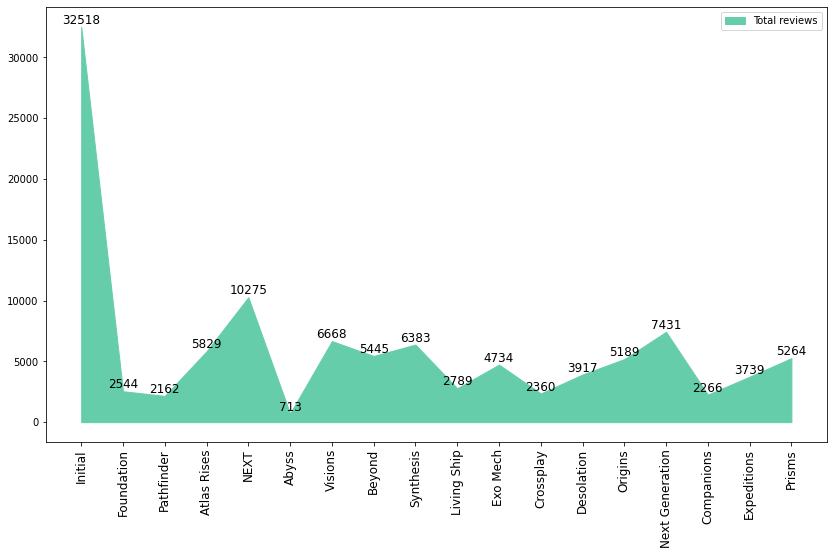

In [24]:
fig, ax = plt.subplots(figsize=(14, 8))

plt.fill_between(patches, pre_positive_patch_review_count, label='Total reviews', color='mediumaquamarine')
plt.xticks(rotation='vertical', size=12)
for index in range(len(patches)):
    ax.text(patches[index], pre_positive_patch_review_count[index], pre_positive_patch_review_count[index], ha='center', va='bottom', size=12)

plt.legend()

plt.show()

In [25]:
pre_positive_patch_review_count_positive = [
    initial_positives.count()[0],
    foundation_positives.count()[0],
    pathfinder_positives.count()[0],
    atlas_rises_positives.count()[0],
    next_positives.count()[0],
    abyss_positives.count()[0],
    visions_positives.count()[0],
    beyond_positives.count()[0],
    synthesis_positives.count()[0],
    living_ship_positives.count()[0],
    exo_mech_positives.count()[0],
    crossplay_positives.count()[0],
    desolation_positives.count()[0],
    origins_positives.count()[0],
    next_gen_positives.count()[0],
    companions_positives.count()[0],
    expeditions_positives.count()[0],
    prisms_positives.count()[0]
]
pre_positive_patch_review_count_negative = [
    initial_negatives.count()[0],
    foundation_negatives.count()[0],
    pathfinder_negatives.count()[0],
    atlas_rises_negatives.count()[0],
    next_negatives.count()[0],
    abyss_negatives.count()[0],
    visions_negatives.count()[0],
    beyond_negatives.count()[0],
    synthesis_negatives.count()[0],
    living_ship_negatives.count()[0],
    exo_mech_negatives.count()[0],
    crossplay_negatives.count()[0],
    desolation_negatives.count()[0],
    origins_negatives.count()[0],
    next_gen_negatives.count()[0],
    companions_negatives.count()[0],
    expeditions_negatives.count()[0],
    prisms_negatives.count()[0]
]

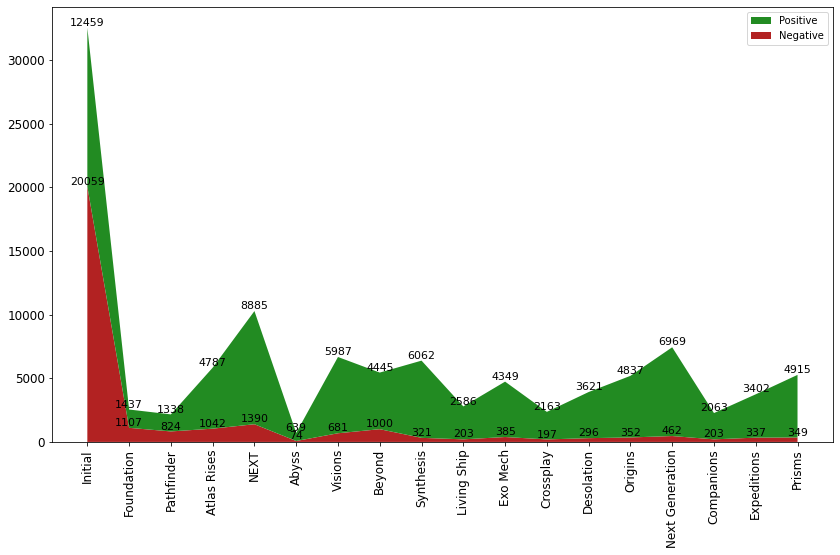

In [26]:
population_by_continent = {
    'Negative': pre_positive_patch_review_count_negative,
    'Positive': pre_positive_patch_review_count_positive
}

fig, ax = plt.subplots(figsize=(14, 8))

ax.stackplot(patches, population_by_continent.values(), labels=population_by_continent.keys(), colors=['firebrick', 'forestgreen'])
plt.xticks(rotation='vertical', size=12)
plt.yticks(size=12)
plt.legend(loc='upper right', reverse=True)

for index in range(len(patches)):
    ax.text(patches[index], pre_positive_patch_review_count_positive[index]+pre_positive_patch_review_count_negative[index], pre_positive_patch_review_count_positive[index], ha='center', va='bottom', size=11)
    ax.text(patches[index], pre_positive_patch_review_count_negative[index], pre_positive_patch_review_count_negative[index], ha='center', va='bottom', size=11)

plt.show()

With about 32,000 reviews and a roughly 62%-38% split breaking for negative reviews, the <i>Initial</i> patch was flooded with negative reviews that really left <b>No Man's Sky</b> in a massive hole. But after some titanic efforts from the <i>Atlas Rises</i>, <i>NEXT</i>, and <i>Visions</i> patches, the game re-earned the community's trust and the positive ratings that followed really helped fill what seemed like a bottomless (negative) pit.

<i>NEXT</i>, the only other patch with over 10,000 reviews, was overwhelmingly well received because <b>Hello Games</b> finally gave the players something they were promised and have always wanted: <i>Multiplayer</i>. As <i>Atlas Rises</i> already made the game significantly more playable, the introduction of multiplayer was the one-two punch that made it easier for older players to return and newer players to experience something worthwhile.

#### How did the reviews from single reviewers break down?

In [27]:
pre_positive_single_review_count = [
    (initial_positives.loc[(initial_positives['Total Reviews'] == 1)].count()[0]+initial_negatives.loc[(initial_negatives['Total Reviews'] == 1)].count()[0]),
    (foundation_positives.loc[(foundation_positives['Total Reviews'] == 1)].count()[0]+foundation_negatives.loc[(foundation_negatives['Total Reviews'] == 1)].count()[0]),
    (pathfinder_positives.loc[(pathfinder_positives['Total Reviews'] == 1)].count()[0]+pathfinder_negatives.loc[(pathfinder_negatives['Total Reviews'] == 1)].count()[0]),
    (atlas_rises_positives.loc[(atlas_rises_positives['Total Reviews'] == 1)].count()[0]+atlas_rises_negatives.loc[(atlas_rises_negatives['Total Reviews'] == 1)].count()[0]),
    (next_positives.loc[(next_positives['Total Reviews'] == 1)].count()[0]+next_negatives.loc[(next_negatives['Total Reviews'] == 1)].count()[0]),
    (abyss_positives.loc[(abyss_positives['Total Reviews'] == 1)].count()[0]+abyss_negatives.loc[(abyss_negatives['Total Reviews'] == 1)].count()[0]),
    (visions_positives.loc[(visions_positives['Total Reviews'] == 1)].count()[0]+visions_negatives.loc[(visions_negatives['Total Reviews'] == 1)].count()[0]),
    (beyond_positives.loc[(beyond_positives['Total Reviews'] == 1)].count()[0]+beyond_negatives.loc[(beyond_negatives['Total Reviews'] == 1)].count()[0]),
    (synthesis_positives.loc[(synthesis_positives['Total Reviews'] == 1)].count()[0]+synthesis_negatives.loc[(synthesis_negatives['Total Reviews'] == 1)].count()[0]),
    (living_ship_positives.loc[(living_ship_positives['Total Reviews'] == 1)].count()[0]+living_ship_negatives.loc[(living_ship_negatives['Total Reviews'] == 1)].count()[0]),
    (exo_mech_positives.loc[(exo_mech_positives['Total Reviews'] == 1)].count()[0]+exo_mech_negatives.loc[(exo_mech_negatives['Total Reviews'] == 1)].count()[0]),
    (crossplay_positives.loc[(crossplay_positives['Total Reviews'] == 1)].count()[0]+crossplay_negatives.loc[(crossplay_negatives['Total Reviews'] == 1)].count()[0]),
    (desolation_positives.loc[(desolation_positives['Total Reviews'] == 1)].count()[0]+desolation_negatives.loc[(desolation_negatives['Total Reviews'] == 1)].count()[0]),
    (origins_positives.loc[(origins_positives['Total Reviews'] == 1)].count()[0]+origins_negatives.loc[(origins_negatives['Total Reviews'] == 1)].count()[0]),
    (next_gen_positives.loc[(next_gen_positives['Total Reviews'] == 1)].count()[0]+next_gen_negatives.loc[(next_gen_negatives['Total Reviews'] == 1)].count()[0]),
    (companions_positives.loc[(companions_positives['Total Reviews'] == 1)].count()[0]+companions_negatives.loc[(companions_negatives['Total Reviews'] == 1)].count()[0]),
    (expeditions_positives.loc[(expeditions_positives['Total Reviews'] == 1)].count()[0]+expeditions_negatives.loc[(expeditions_negatives['Total Reviews'] == 1)].count()[0]),
    (prisms_positives.loc[(prisms_positives['Total Reviews'] == 1)].count()[0]+prisms_negatives.loc[(prisms_negatives['Total Reviews'] == 1)].count()[0])
]

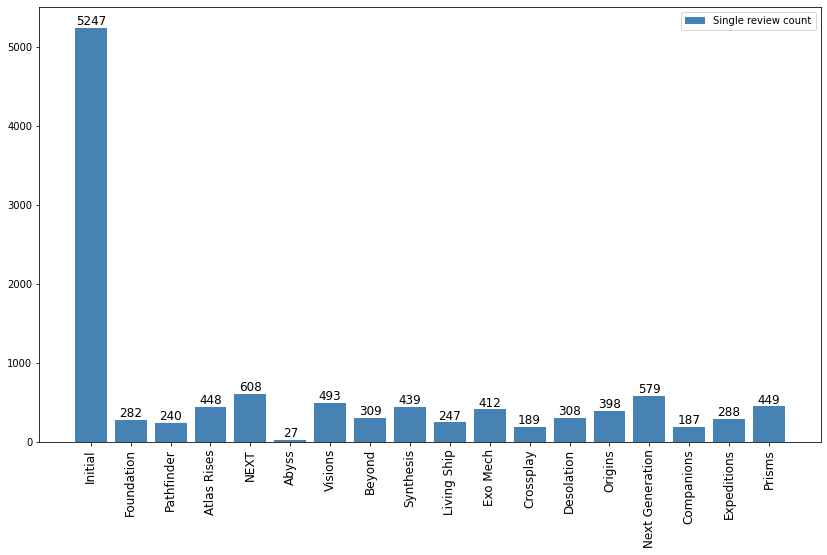

In [28]:
fig, ax = plt.subplots(figsize=(14, 8))

plt.bar(patches, pre_positive_single_review_count, label='Single review count', color='steelblue')
plt.xticks(rotation='vertical', size=12)
for index in range(len(patches)):
    ax.text(patches[index], pre_positive_single_review_count[index], pre_positive_single_review_count[index], ha='center', va='bottom', size=12)

plt.legend()

plt.show()

In [29]:
pre_positive_single_review_count_positive = [
    initial_positives.loc[(initial_positives['Total Reviews'] == 1)].count()[0],
    foundation_positives.loc[(foundation_positives['Total Reviews'] == 1)].count()[0],
    pathfinder_positives.loc[(pathfinder_positives['Total Reviews'] == 1)].count()[0],
    atlas_rises_positives.loc[(atlas_rises_positives['Total Reviews'] == 1)].count()[0],
    next_positives.loc[(next_positives['Total Reviews'] == 1)].count()[0],
    abyss_positives.loc[(abyss_positives['Total Reviews'] == 1)].count()[0],
    visions_positives.loc[(visions_positives['Total Reviews'] == 1)].count()[0],
    beyond_positives.loc[(beyond_positives['Total Reviews'] == 1)].count()[0],
    synthesis_positives.loc[(synthesis_positives['Total Reviews'] == 1)].count()[0],
    living_ship_positives.loc[(living_ship_positives['Total Reviews'] == 1)].count()[0],
    exo_mech_positives.loc[(exo_mech_positives['Total Reviews'] == 1)].count()[0],
    crossplay_positives.loc[(crossplay_positives['Total Reviews'] == 1)].count()[0],
    desolation_positives.loc[(desolation_positives['Total Reviews'] == 1)].count()[0],
    origins_positives.loc[(origins_positives['Total Reviews'] == 1)].count()[0],
    next_gen_positives.loc[(next_gen_positives['Total Reviews'] == 1)].count()[0],
    companions_positives.loc[(companions_positives['Total Reviews'] == 1)].count()[0],
    expeditions_positives.loc[(expeditions_positives['Total Reviews'] == 1)].count()[0],
    prisms_positives.loc[(prisms_positives['Total Reviews'] == 1)].count()[0]
]
pre_positive_single_review_count_negative = [
    initial_negatives.loc[(initial_negatives['Total Reviews'] == 1)].count()[0],
    foundation_negatives.loc[(foundation_negatives['Total Reviews'] == 1)].count()[0],
    pathfinder_negatives.loc[(pathfinder_negatives['Total Reviews'] == 1)].count()[0],
    atlas_rises_negatives.loc[(atlas_rises_negatives['Total Reviews'] == 1)].count()[0],
    next_negatives.loc[(next_negatives['Total Reviews'] == 1)].count()[0],
    abyss_negatives.loc[(abyss_negatives['Total Reviews'] == 1)].count()[0],
    visions_negatives.loc[(visions_negatives['Total Reviews'] == 1)].count()[0],
    beyond_negatives.loc[(beyond_negatives['Total Reviews'] == 1)].count()[0],
    synthesis_negatives.loc[(synthesis_negatives['Total Reviews'] == 1)].count()[0],
    living_ship_negatives.loc[(living_ship_negatives['Total Reviews'] == 1)].count()[0],
    exo_mech_negatives.loc[(exo_mech_negatives['Total Reviews'] == 1)].count()[0],
    crossplay_negatives.loc[(crossplay_negatives['Total Reviews'] == 1)].count()[0],
    desolation_negatives.loc[(desolation_negatives['Total Reviews'] == 1)].count()[0],
    origins_negatives.loc[(origins_negatives['Total Reviews'] == 1)].count()[0],
    next_gen_negatives.loc[(next_gen_negatives['Total Reviews'] == 1)].count()[0],
    companions_negatives.loc[(companions_negatives['Total Reviews'] == 1)].count()[0],
    expeditions_negatives.loc[(expeditions_negatives['Total Reviews'] == 1)].count()[0],
    prisms_negatives.loc[(prisms_negatives['Total Reviews'] == 1)].count()[0]
]

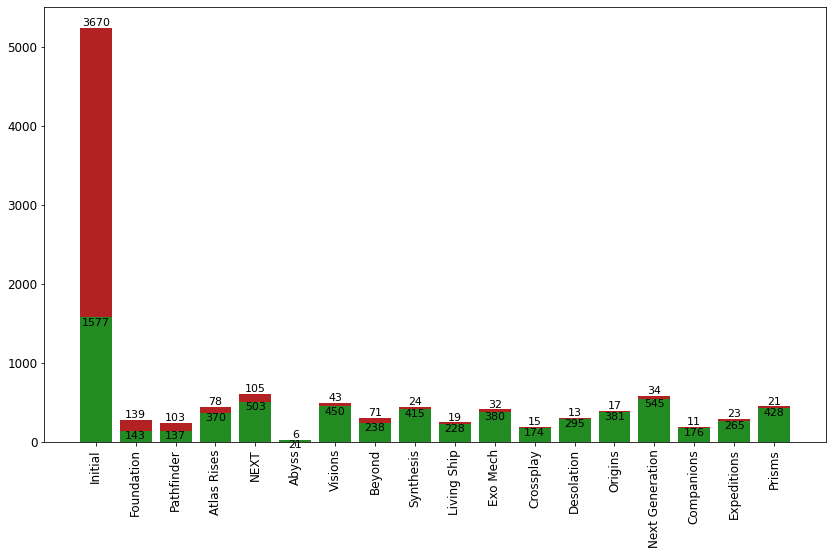

In [30]:
fig, ax = plt.subplots(figsize=(14, 8))

plt.bar(patches, pre_positive_single_review_count_positive, color='forestgreen')
plt.bar(patches, pre_positive_single_review_count_negative, bottom=pre_positive_single_review_count_positive, color='firebrick')
plt.xticks(rotation='vertical', size=12)
plt.yticks(size=12)

for index in range(len(patches)):
    ax.text(patches[index], pre_positive_single_review_count_positive[index], pre_positive_single_review_count_positive[index], ha='center', va='top', size=11)
    ax.text(patches[index], pre_positive_single_review_count_positive[index]+pre_positive_single_review_count_negative[index], pre_positive_single_review_count_negative[index], ha='center', va='bottom', size=11)

plt.show()

#### How did the reviews from the most prolific reviewers break down?

In [31]:
pre_positive_prolific_reviews_over_1000 = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Total Reviews'] > 1000)]
pre_positive_prolific_reviews_over_1000_positive = pre_positive_prolific_reviews_over_1000.loc[(mnsdata_pre_positive['Recommended?'] == True)].count()[0]
pre_positive_prolific_reviews_over_1000_negative = pre_positive_prolific_reviews_over_1000.loc[(mnsdata_pre_positive['Recommended?'] == False)].count()[0]

print(f'{pre_positive_prolific_reviews_over_1000_positive} positive reviews.')
print(f'{pre_positive_prolific_reviews_over_1000_negative} negative reviews.')
print(f'{round(100*pre_positive_prolific_reviews_over_1000_positive/pre_positive_prolific_reviews_over_1000.count()[0], 2)}% rating.')

19 positive reviews.
0 negative reviews.
100.0% rating.


#### How did the reviews from slightly less prolific reviewers break down?

In [32]:
pre_positive_prolific_reviews_between_100_and_1000 = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Total Reviews'] > 100) & (mnsdata_pre_positive['Total Reviews'] <= 1000)]
pre_positive_prolific_reviews_between_100_and_1000_positive = pre_positive_prolific_reviews_between_100_and_1000.loc[(mnsdata_pre_positive['Recommended?'] == True)].count()[0]
pre_positive_prolific_reviews_between_100_and_1000_negative = pre_positive_prolific_reviews_between_100_and_1000.loc[(mnsdata_pre_positive['Recommended?'] == False)].count()[0]

print(f'{pre_positive_prolific_reviews_between_100_and_1000_positive} positive reviews.')
print(f'{pre_positive_prolific_reviews_between_100_and_1000_negative} negative reviews.')
print(f'{round(100*pre_positive_prolific_reviews_between_100_and_1000_positive/pre_positive_prolific_reviews_between_100_and_1000.count()[0], 2)}% rating.')

2096 positive reviews.
601 negative reviews.
77.72% rating.


#### How did the reviews from Steam and non-Steam purchases break down?

In [33]:
steam_purchase_positive = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Steam Purchase'] == True) & (mnsdata_pre_positive['Recommended?'] == True)].count()[0]
steam_purchase_negative = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Steam Purchase'] == True) & (mnsdata_pre_positive['Recommended?'] == False)].count()[0]
nonsteam_purchase_positive = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Steam Purchase'] == False) & (mnsdata_pre_positive['Recommended?'] == True)].count()[0]
nonsteam_purchase_negative = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Steam Purchase'] == False) & (mnsdata_pre_positive['Recommended?'] == False)].count()[0]

steam_nonsteam_breakdown = [
    steam_purchase_positive,
    nonsteam_purchase_positive,
    steam_purchase_negative,
    nonsteam_purchase_negative
]

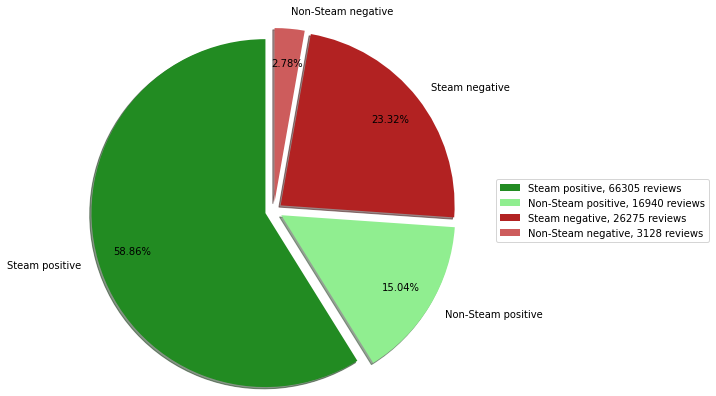

In [34]:
steam_review_categories = ['Steam positive', 'Non-Steam positive', 'Steam negative', 'Non-Steam negative']
posi_nega_color_set = ['forestgreen', 'lightgreen', 'firebrick', 'indianred']

explode = (0.1, 0.1, 0.1, 0.1)

plt.pie(steam_nonsteam_breakdown, labels=steam_review_categories, explode=explode, autopct='%1.2f%%', colors=posi_nega_color_set, shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels=['%s, %1.0f reviews' % (l, s) for l, s in zip(steam_review_categories, steam_nonsteam_breakdown)], bbox_to_anchor=(1.5, 0.5), loc='center left')

plt.show()

#### How much did the reviews correlate with staying power?

In [35]:
pre_positive_postreview_time = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == True)]['Post Review Playing Time']
pre_negative_postreview_time = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == False)]['Post Review Playing Time']

print(f'On average, reviewers who rated the game positively played an extra {round(pre_positive_postreview_time.mean())} hours after their review.')
print(f'On average, reviewers who rated the game negatively played an extra {round(pre_negative_postreview_time.mean())} hours after their review.')

On average, reviewers who rated the game positively played an extra 9623 hours after their review.
On average, reviewers who rated the game negatively played an extra 2500 hours after their review.


2,500 hours (or about 3.4 months) may be a surprising amount for those who gave the game a negative rating, but it most likely meant many came back after hearing the updated state of <b>No Man's Sky</b> and never revised their original rating.

In [36]:
pre_positive_post_review_time_up_to_half_week = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == True) & (mnsdata_pre_positive['Post Review Playing Time'] <= 5040)].count()[0]
pre_positive_post_review_time_up_to_week = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == True) & (mnsdata_pre_positive['Post Review Playing Time'] >= 5041) & (mnsdata_pre_positive['Post Review Playing Time'] <= 10080)].count()[0]
pre_positive_post_review_time_week_more = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == True) & (mnsdata_pre_positive['Post Review Playing Time'] > 10080)].count()[0]

pre_negative_post_review_time_up_to_half_week = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == False) & (mnsdata_pre_positive['Post Review Playing Time'] <= 5040)].count()[0]
pre_negative_post_review_time_up_to_week = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == False) & (mnsdata_pre_positive['Post Review Playing Time'] >= 5041) & (mnsdata_pre_positive['Post Review Playing Time'] <= 10080)].count()[0]
pre_negative_post_review_time_week_more = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == False) & (mnsdata_pre_positive['Post Review Playing Time'] > 10080)].count()[0]

pre_positive_post_review_positive = np.array([
    100*pre_positive_post_review_time_up_to_half_week/(pre_positive_post_review_time_up_to_half_week+pre_positive_post_review_time_up_to_week+pre_positive_post_review_time_week_more),
    100*pre_positive_post_review_time_up_to_week/(pre_positive_post_review_time_up_to_half_week+pre_positive_post_review_time_up_to_week+pre_positive_post_review_time_week_more),
    100*pre_positive_post_review_time_week_more/(pre_positive_post_review_time_up_to_half_week+pre_positive_post_review_time_up_to_week+pre_positive_post_review_time_week_more)
])
pre_positive_post_review_negative = np.array([
    100*pre_negative_post_review_time_up_to_half_week/(pre_negative_post_review_time_up_to_half_week+pre_negative_post_review_time_up_to_week+pre_negative_post_review_time_week_more),
    100*pre_negative_post_review_time_up_to_week/(pre_negative_post_review_time_up_to_half_week+pre_negative_post_review_time_up_to_week+pre_negative_post_review_time_week_more),
    100*pre_negative_post_review_time_week_more/(pre_negative_post_review_time_up_to_half_week+pre_negative_post_review_time_up_to_week+pre_negative_post_review_time_week_more)
])

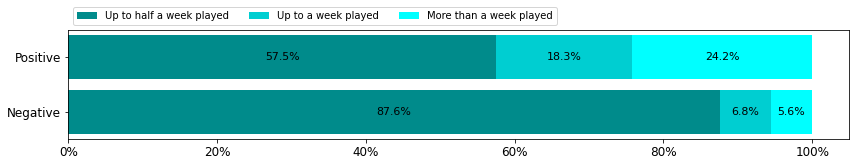

In [37]:
keys = ['Positive', 'Negative']
post_review_timings = ['Up to half a week played', 'Up to a week played', 'More than a week played']
time_color_set = ['darkcyan', 'darkturquoise', 'cyan']

data = np.array(list([pre_positive_post_review_positive, pre_positive_post_review_negative]))
cumulating = data.cumsum(axis=1)

fig, ax = plt.subplots(figsize=(14, 2))
ax.invert_yaxis()
plt.xticks(size=12)
plt.yticks(size=12)

for i, (colname, color) in enumerate(zip(post_review_timings, time_color_set)):
    widths = data[:, i]
    starts = cumulating[:, i] - widths
    rects = ax.barh(keys, widths, left=starts, label=colname, color=color)

    ax.bar_label(rects, fmt='%.1f%%', label_type='center', color='black', size=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.legend(post_review_timings, ncols=len(post_review_timings), bbox_to_anchor=(0, 1), loc='lower left')

plt.show()

Since 94.4% of all negative reviewers only played at most another week after their review, the remaining 5.6% came back and really stayed to give the game another chance after hearing about how much <b>No Man's Sky</b> had changed.

In [38]:
mnsdata_pre_positive.loc[(mnsdata_pre_positive['Recommended?'] == False)].sort_values(by='Post Review Playing Time', ascending=False).head(10)

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase,Date,Anniversary
131325,71003001,0,0,1,79142,847755,768613,0,very buggy due to recent update.,False,False,2020-06-18,4
221398,24854726,4,7,16,1669,438495,436826,11,Graphics look awful (maybe cuz it got badly po...,False,True,2016-08-12,1
131657,70725651,1,0,2,176383,523329,346946,1,"When I approach my freighter, my ship changes ...",False,True,2020-06-13,4
176509,28226244,1,5,13,7742,321460,313718,6,"horrible performance, poorly optimized, and re...",False,True,2016-12-06,1
176140,28653056,0,5,38,764,226024,225260,5,Not buy\n\n1 dick alien / 10 carbon,False,True,2016-12-25,1
109690,90814729,2,2,1,107219,274050,166831,4,Still really buggy.,False,False,2021-04-23,5
127173,74290203,6,5,31,58126,210998,152872,11,Not worth a review. I played nearly 1000 hours...,False,True,2020-08-14,5
218655,24862478,0,0,64,2210,154072,151862,0,This game was/and all hype! All lies! By far t...,False,True,2017-07-03,1
179435,26680545,0,3,2,13890,164743,150853,3,This could be a great game but lack of fulfill...,False,True,2016-11-18,1
116704,83000192,2,2,1,124211,271462,147251,4,After numerous updates and over 2000 hours of ...,False,True,2020-12-23,5


As expected! Half of the top 10 reviews with the highest post-review playing time came from the early days of launch, and the review with the highest amount of post-review playing time from that era clocked in another <b>436,826</b> minutes afterwards, which is nearly <b>10 more months</b> of gaming time!

#### How much did the reviews from each patch correlate with staying power?

In [39]:
pre_positive_patch_engagement_positive = [
    initial_positives['Post Review Playing Time'].mean(),
    foundation_positives['Post Review Playing Time'].mean(),
    pathfinder_positives['Post Review Playing Time'].mean(),
    atlas_rises_positives['Post Review Playing Time'].mean(),
    next_positives['Post Review Playing Time'].mean(),
    abyss_positives['Post Review Playing Time'].mean(),
    visions_positives['Post Review Playing Time'].mean(),
    beyond_positives['Post Review Playing Time'].mean(),
    synthesis_positives['Post Review Playing Time'].mean(),
    living_ship_positives['Post Review Playing Time'].mean(),
    exo_mech_positives['Post Review Playing Time'].mean(),
    crossplay_positives['Post Review Playing Time'].mean(),
    desolation_positives['Post Review Playing Time'].mean(),
    origins_positives['Post Review Playing Time'].mean(),
    next_gen_positives['Post Review Playing Time'].mean(),
    companions_positives['Post Review Playing Time'].mean(),
    expeditions_positives['Post Review Playing Time'].mean(),
    prisms_positives['Post Review Playing Time'].mean()
]
pre_positive_patch_engagement_negative = [
    initial_negatives['Post Review Playing Time'].mean(),
    foundation_negatives['Post Review Playing Time'].mean(),
    pathfinder_negatives['Post Review Playing Time'].mean(),
    atlas_rises_negatives['Post Review Playing Time'].mean(),
    next_negatives['Post Review Playing Time'].mean(),
    abyss_negatives['Post Review Playing Time'].mean(),
    visions_negatives['Post Review Playing Time'].mean(),
    beyond_negatives['Post Review Playing Time'].mean(),
    synthesis_negatives['Post Review Playing Time'].mean(),
    living_ship_negatives['Post Review Playing Time'].mean(),
    exo_mech_negatives['Post Review Playing Time'].mean(),
    crossplay_negatives['Post Review Playing Time'].mean(),
    desolation_negatives['Post Review Playing Time'].mean(),
    origins_negatives['Post Review Playing Time'].mean(),
    next_gen_negatives['Post Review Playing Time'].mean(),
    companions_negatives['Post Review Playing Time'].mean(),
    expeditions_negatives['Post Review Playing Time'].mean(),
    prisms_negatives['Post Review Playing Time'].mean()
]

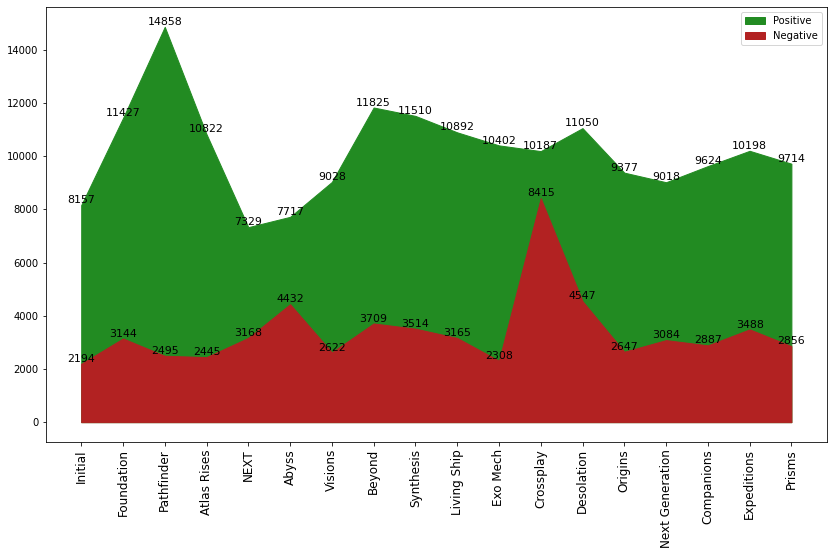

In [40]:
fig, ax = plt.subplots(figsize=(14, 8))

plt.fill_between(patches, pre_positive_patch_engagement_positive, label='Positive', color='forestgreen')
plt.fill_between(patches, pre_positive_patch_engagement_negative, label='Negative', color='firebrick')
plt.xticks(rotation='vertical', size=12)
plt.legend(loc='upper right')

for index in range(len(patches)):
    ax.text(patches[index], round(pre_positive_patch_engagement_positive[index]), round(pre_positive_patch_engagement_positive[index]), ha='center', va='bottom', size=11)
    ax.text(patches[index], round(pre_positive_patch_engagement_negative[index]), round(pre_positive_patch_engagement_negative[index]), ha='center', va='bottom', size=11)

plt.show()

Everything looks pretty standard with the exception of the negative numbers spiking during the <i>Crossplay</i> patch. Was that just a few people who decided they were going to keep playing non-stop and completely distort the average?

In [41]:
crossplay_negatives.sort_values(by='Post Review Playing Time', ascending=False).head(5)

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase,Date,Anniversary
131325,71003001,0,0,1,79142,847755,768613,0,very buggy due to recent update.,False,False,2020-06-18,4
131657,70725651,1,0,2,176383,523329,346946,1,"When I approach my freighter, my ship changes ...",False,True,2020-06-13,4
131668,70709437,3,1,7,23460,84012,60552,4,"Downloaded NMS after the video ""The Engoodenin...",False,False,2020-06-13,4
130441,71856536,0,3,28,2799,42446,39647,3,"Tedious slog with no reward and ""procedural ge...",False,True,2020-07-02,4
130638,71676247,3,3,15,17393,53102,35709,6,"WHAT A HOLLOW, CRYPTIC, NONSENSE GAME. GREAT I...",False,True,2020-06-29,4


Called it! Two individuals who clocked in at <b>768,613 minutes</b> (about <b>17.5 months</b>) and <b>346,946 minutes</b> (about <b>7.9 months</b>).

### Part II: Path To Positive Overall.

### Initial (Release 1.00)

#### Which initial review garnered the most upvotes?

In [42]:
initial_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] <= '2016-11-25')]
initial_patch_upvoted_count = initial_patch.loc[(initial_patch['Up'] == max(initial_patch['Up']))]['Reactions'].values[0]
initial_patch_upvoted_review = initial_patch.loc[(initial_patch['Up'] == max(initial_patch['Up']))]['Reviews'].values[0]
initial_patch_upvoted_funny = initial_patch.loc[(initial_patch['Up'] == max(initial_patch['Up']))]['Funny'].values[0]
initial_patch_upvoted_upvote = initial_patch.loc[(initial_patch['Up'] == max(initial_patch['Up']))]['Up'].values[0]
initial_patch_upvoted_date = initial_patch.loc[(initial_patch['Up'] == max(initial_patch['Up']))]['Date'].values[0]

print(f'{initial_patch_upvoted_review}')
print(f'---\nSubmitted on {initial_patch_upvoted_date}, this review garnered {initial_patch_upvoted_count} reactions ({initial_patch_upvoted_funny} laughs and {initial_patch_upvoted_upvote} upvotes).')

A mile wide but an inch deep. I can not express it better.
---
Submitted on 2016-08-15, this review garnered 14814 reactions (2487 laughs and 12327 upvotes).


Because the previous review that had the most reactions was also written during the early days of launch, this review has the most upvotes. The sentiment is no different as the reviewer encapsulated his/her displeasure in two short sentences.

#### How did the initial reviews break down by reactions?

In [43]:
initial_reactions_over_100 = initial_patch.loc[(initial_patch['Reactions'] > 100)]
initial_reactions_between_51_and_100 = initial_patch.loc[(initial_patch['Reactions'] > 50) & (initial_patch['Reactions'] <= 100)]
initial_reactions_between_26_and_50 = initial_patch.loc[(initial_patch['Reactions'] > 25) & (initial_patch['Reactions'] <= 50)]
initial_reactions_between_11_and_25 = initial_patch.loc[(initial_patch['Reactions'] > 10) & (initial_patch['Reactions'] <= 25)]
initial_reactions_between_1_and_10 = initial_patch.loc[(initial_patch['Reactions'] >= 1) & (initial_patch['Reactions'] <= 10)]
initial_reactions_at_0 = initial_patch.loc[(initial_patch['Reactions'] == 0)]

initial_reactions_by_category = [
    initial_reactions_over_100.count()[0],
    initial_reactions_between_51_and_100.count()[0],
    initial_reactions_between_26_and_50.count()[0],
    initial_reactions_between_11_and_25.count()[0],
    initial_reactions_between_1_and_10.count()[0],
    initial_reactions_at_0.count()[0]
]

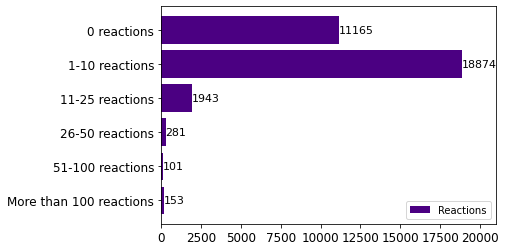

In [44]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, initial_reactions_by_category, label='Reactions', color='indigo')
plt.xticks(size=12)
plt.xlim(0, 21000)
plt.yticks(rotation='horizontal', size=12)

for index in range(len(reactions_categories)):
    ax.text(initial_reactions_by_category[index], reactions_categories[index], initial_reactions_by_category[index], rotation='horizontal', va='center', size=11)

plt.legend(loc='lower right')

plt.show()

In [45]:
initial_reactions_over_100_positive = initial_reactions_over_100.loc[(initial_patch['Recommended?'] == True)].count()[0]
initial_reactions_over_100_negative = initial_reactions_over_100.loc[(initial_patch['Recommended?'] == False)].count()[0]
initial_reactions_between_51_and_100_positive = initial_reactions_between_51_and_100.loc[(initial_patch['Recommended?'] == True)].count()[0]
initial_reactions_between_51_and_100_negative = initial_reactions_between_51_and_100.loc[(initial_patch['Recommended?'] == False)].count()[0]
initial_reactions_between_26_and_50_positive = initial_reactions_between_26_and_50.loc[(initial_patch['Recommended?'] == True)].count()[0]
initial_reactions_between_26_and_50_negative = initial_reactions_between_26_and_50.loc[(initial_patch['Recommended?'] == False)].count()[0]
initial_reactions_between_11_and_25_positive = initial_reactions_between_11_and_25.loc[(initial_patch['Recommended?'] == True)].count()[0]
initial_reactions_between_11_and_25_negative = initial_reactions_between_11_and_25.loc[(initial_patch['Recommended?'] == False)].count()[0]
initial_reactions_between_1_and_10_positive = initial_reactions_between_1_and_10.loc[(initial_patch['Recommended?'] == True)].count()[0]
initial_reactions_between_1_and_10_negative = initial_reactions_between_1_and_10.loc[(initial_patch['Recommended?'] == False)].count()[0]
initial_reactions_at_0_positive = initial_reactions_at_0.loc[(initial_patch['Recommended?'] == True)].count()[0]
initial_reactions_at_0_negative = initial_reactions_at_0.loc[(initial_patch['Recommended?'] == False)].count()[0]

initial_reactions_by_category_positive = [
    initial_reactions_over_100_positive,
    initial_reactions_between_51_and_100_positive,
    initial_reactions_between_26_and_50_positive,
    initial_reactions_between_11_and_25_positive,
    initial_reactions_between_1_and_10_positive,
    initial_reactions_at_0_positive
]
initial_reactions_by_category_negative = [
    initial_reactions_over_100_negative,
    initial_reactions_between_51_and_100_negative,
    initial_reactions_between_26_and_50_negative,
    initial_reactions_between_11_and_25_negative,
    initial_reactions_between_1_and_10_negative,
    initial_reactions_at_0_negative
]

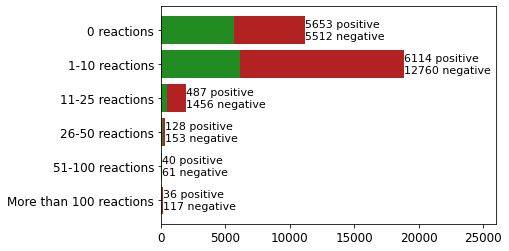

In [46]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, initial_reactions_by_category_positive, color='forestgreen')
plt.barh(reactions_categories, initial_reactions_by_category_negative, left=initial_reactions_by_category_positive, color='firebrick')
plt.xticks(rotation='horizontal', size=12)
plt.xlim(0, 26000)
plt.yticks(size=12)

for index in range(len(reactions_categories)):
    ax.text(initial_reactions_by_category_positive[index]+initial_reactions_by_category_negative[index], reactions_categories[index], f'{initial_reactions_by_category_positive[index]} positive\n{initial_reactions_by_category_negative[index]} negative', ha='left', va='center', size=11)

plt.show()

#### How did the initial reviews break down by different time intervals?

In [47]:
initial_first_day_positives = initial_positives.loc[(initial_positives['Date'] == '2016-08-12')].count()[0]
initial_first_day_negatives = initial_negatives.loc[(initial_negatives['Date'] == '2016-08-12')].count()[0]
initial_first_week_positives = initial_positives.loc[(initial_positives['Date'] <= '2016-08-18')].count()[0]
initial_first_week_negatives = initial_negatives.loc[(initial_negatives['Date'] <= '2016-08-18')].count()[0]
initial_first_month_positives = initial_positives.loc[(initial_positives['Date'] <= '2016-09-11')].count()[0]
initial_first_month_negatives = initial_negatives.loc[(initial_negatives['Date'] <= '2016-09-11')].count()[0]

initial_first_positives = [initial_first_day_positives, initial_first_week_positives, initial_first_month_positives]
initial_first_negatives = [initial_first_day_negatives, initial_first_week_negatives, initial_first_month_negatives]

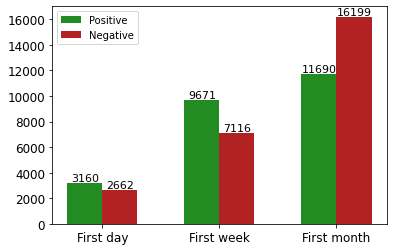

In [48]:
fig, ax = plt.subplots()
first_categories = ['First month', 'First week', 'First day']
width = 0.3

plt.bar(np.arange(len(initial_first_positives))-width/2, initial_first_positives, width, label='Positive', color='forestgreen')
plt.bar(np.arange(len(initial_first_negatives))+width/2, initial_first_negatives, width, label='Negative', color='firebrick')
plt.xticks(range(len(first_categories)-1,-1,-1), first_categories, rotation='horizontal', size=12)
plt.yticks(size=12)

for index in range(len(first_categories)):
    ax.text(np.arange(len(initial_first_positives))[index]-width/2, initial_first_positives[index], initial_first_positives[index], ha='center', va='bottom', size=11)
    ax.text(np.arange(len(initial_first_negatives))[index]+width/2, initial_first_negatives[index], initial_first_negatives[index], ha='center', va='bottom', size=11)

plt.legend()

plt.show()

#### How did the initial reviews from the most prolific reviewers break down?

In [49]:
initial_prolific_reviews_over_250 = initial_patch.loc[(initial_patch['Total Reviews'] > 250)]
initial_prolific_reviews_over_250_positive = initial_prolific_reviews_over_250.loc[(initial_patch['Recommended?'] == True)].count()[0]
initial_prolific_reviews_over_250_negative = initial_prolific_reviews_over_250.loc[(initial_patch['Recommended?'] == False)].count()[0]

print(f'{initial_prolific_reviews_over_250_positive} positive reviews.')
print(f'{initial_prolific_reviews_over_250_negative} negative reviews.')
print(f'{round(100*initial_prolific_reviews_over_250_positive/initial_prolific_reviews_over_250.count()[0], 2)}% rating.')

18 positive reviews.
19 negative reviews.
48.65% rating.


#### How did the initial reviews from slightly less prolific reviewers break down?

In [50]:
initial_prolific_reviews_between_100_and_250 = initial_patch.loc[(initial_patch['Total Reviews'] > 100) & (initial_patch['Total Reviews'] <= 250)]
initial_prolific_reviews_between_100_and_250_positive = initial_prolific_reviews_between_100_and_250.loc[(initial_prolific_reviews_between_100_and_250['Recommended?'] == True)].count()[0]
initial_prolific_reviews_between_100_and_250_negative = initial_prolific_reviews_between_100_and_250.loc[(initial_prolific_reviews_between_100_and_250['Recommended?'] == False)].count()[0]

print(f'{initial_prolific_reviews_between_100_and_250_positive} positive reviews.')
print(f'{initial_prolific_reviews_between_100_and_250_negative} negative reviews.')
print(f'{round(100*initial_prolific_reviews_between_100_and_250_positive/initial_prolific_reviews_between_100_and_250.count()[0], 2)}% rating.')

148 positive reviews.
163 negative reviews.
47.59% rating.


#### How did the initial reviews from Steam and non-Steam purchases break down?

In [51]:
initial_steam_purchase_positive = initial_positives.loc[(initial_positives['Steam Purchase'] == True)].count()[0]
initial_steam_purchase_negative = initial_negatives.loc[(initial_negatives['Steam Purchase'] == True)].count()[0]
initial_nonsteam_purchase_positive = initial_positives.loc[(initial_positives['Steam Purchase'] == False)].count()[0]
initial_nonsteam_purchase_negative = initial_negatives.loc[(initial_negatives['Steam Purchase'] == False)].count()[0]

initial_steam_nonsteam_breakdown = [
    initial_steam_purchase_positive,
    initial_nonsteam_purchase_positive,
    initial_steam_purchase_negative,
    initial_nonsteam_purchase_negative
]

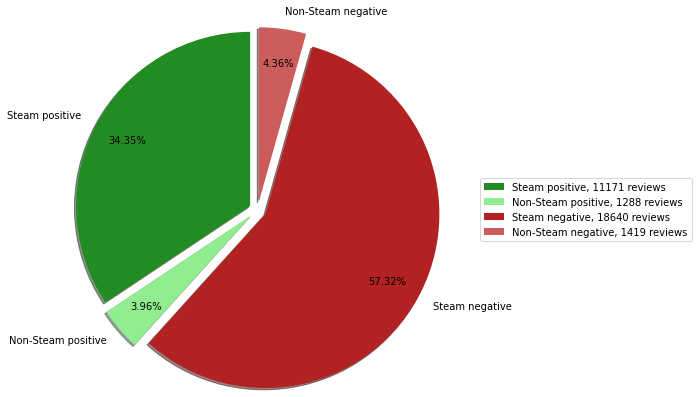

In [52]:
explode = (0.1, 0.1, 0.1, 0.1)

plt.pie(initial_steam_nonsteam_breakdown, labels=steam_review_categories, explode=explode, autopct='%1.2f%%', colors=posi_nega_color_set, shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels=['%s, %1.0f reviews' % (l, s) for l, s in zip(steam_review_categories, initial_steam_nonsteam_breakdown)], bbox_to_anchor=(1.5, 0.5), loc='center left')

plt.show()

#### How much did the initial reviews correlate with staying power?

In [53]:
initial_positive_postreview_time = initial_positives['Post Review Playing Time']
initial_negative_postreview_time = initial_negatives['Post Review Playing Time']

print(f'On average, reviewers who rated the game positively played an extra {round(initial_positive_postreview_time.mean())} hours after their review.')
print(f'On average, reviewers who rated the game negatively played an extra {round(initial_negative_postreview_time.mean())} hours after their review.')

On average, reviewers who rated the game positively played an extra 8157 hours after their review.
On average, reviewers who rated the game negatively played an extra 2194 hours after their review.


In [54]:
initial_positive_post_review_time_up_to_half_week = initial_positives.loc[(initial_positives['Post Review Playing Time'] < 5040)].count()[0]
initial_positive_post_review_time_up_to_week = initial_positives.loc[(initial_positives['Post Review Playing Time'] >= 5040) & (initial_positives['Post Review Playing Time'] < 10080)].count()[0]
initial_positive_post_review_time_week_more = initial_positives.loc[(initial_positives['Post Review Playing Time'] >= 10080)].count()[0]

initial_negative_post_review_time_up_to_half_week = initial_negatives.loc[(initial_negatives['Post Review Playing Time'] < 5040)].count()[0]
initial_negative_post_review_time_up_to_week = initial_negatives.loc[(initial_negatives['Post Review Playing Time'] >= 5040) & (initial_negatives['Post Review Playing Time'] < 10080)].count()[0]
initial_negative_post_review_time_week_more = initial_negatives.loc[(initial_negatives['Post Review Playing Time'] >= 10080)].count()[0]

initial_positive_data = np.array([100*initial_positive_post_review_time_up_to_half_week/(initial_positive_post_review_time_up_to_half_week+initial_positive_post_review_time_up_to_week+initial_positive_post_review_time_week_more),
                                  100*initial_positive_post_review_time_up_to_week/(initial_positive_post_review_time_up_to_half_week+initial_positive_post_review_time_up_to_week+initial_positive_post_review_time_week_more),
                                  100*initial_positive_post_review_time_week_more/(initial_positive_post_review_time_up_to_half_week+initial_positive_post_review_time_up_to_week+initial_positive_post_review_time_week_more)])
initial_negative_data = np.array([100*initial_negative_post_review_time_up_to_half_week/(initial_negative_post_review_time_up_to_half_week+initial_negative_post_review_time_up_to_week+initial_negative_post_review_time_week_more),
                                  100*initial_negative_post_review_time_up_to_week/(initial_negative_post_review_time_up_to_half_week+initial_negative_post_review_time_up_to_week+initial_negative_post_review_time_week_more),
                                  100*initial_negative_post_review_time_week_more/(initial_negative_post_review_time_up_to_half_week+initial_negative_post_review_time_up_to_week+initial_negative_post_review_time_week_more)])

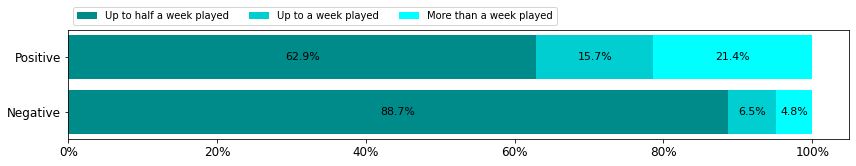

In [55]:
data = np.array(list([initial_positive_data, initial_negative_data]))
data_cum = data.cumsum(axis=1)

fig, ax = plt.subplots(figsize=(14, 2))
ax.invert_yaxis()
plt.xticks(size=12)
plt.yticks(size=12)

for i, (colname, color) in enumerate(zip(post_review_timings, time_color_set)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = ax.barh(keys, widths, left=starts, label=colname, color=color)

    ax.bar_label(rects, fmt='%.1f%%', label_type='center', color='black', size=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.legend(post_review_timings, ncols=len(post_review_timings), bbox_to_anchor=(0, 1), loc='lower left')

plt.show()

### Atlas Rises (Release 1.30)

#### Which Atlas Rises review garnered the most reactions?

In [56]:
ar_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2017-08-11') & (mnsdata_pre_positive['Date'] <= '2018-07-23')]
ar_patch_reactions_count = ar_patch.loc[(ar_patch['Reactions'] == max(ar_patch['Reactions']))]['Reactions'].values[0]
ar_patch_reactions_review = ar_patch.loc[(ar_patch['Reactions'] == max(ar_patch['Reactions']))]['Reviews'].values[0]
ar_patch_reactions_funny = ar_patch.loc[(ar_patch['Reactions'] == max(ar_patch['Reactions']))]['Funny'].values[0]
ar_patch_reactions_upvote = ar_patch.loc[(ar_patch['Reactions'] == max(ar_patch['Reactions']))]['Up'].values[0]
ar_patch_reactions_date = ar_patch.loc[(ar_patch['Reactions'] == max(ar_patch['Reactions']))]['Date'].values[0]

print(f'{ar_patch_reactions_review}')
print(f'---\nSubmitted on {ar_patch_reactions_date}, this review garnered {ar_patch_reactions_count} reactions ({ar_patch_reactions_funny} laughs and {ar_patch_reactions_upvote} upvotes).')

Overhyped, poorly optimized, indie game made by 15 people, being sold for AAA price. It's shallow, empty, repetitive and boring. Their 18 quintillion planets are just a bunch of re-color of the same assets, randomly generated with different combinations. Their representation of the universe is inaccurate, every single planet and moon i've seen is inhabited with life and/or vegetation, there are no gas giants, no ring systems. Also, black holes are literally portals. So astronomy enthusiasts, beware, if you thought this would be a space sim you're wrong, it is vaguely based on the real universe. 

About the gameplay, you scan stuff, you mine materials, find some outposts, fill out your ship and your gear, run out of inventory space, go to the nearest space station, sell your sh*t, and then you move on the the next planet. That's basically what you do until you reach the center of the galaxy for a NG+. About the combat, the ground and space shooting are mediocre at best. All planetary ou

<i>Atlas Rises</i>, while generally seen as the patch that turned the game around, definitely still had its detractors. The review is not unreasonable at all since it listed all the things the game still fell short of and how much it did not compare to <b>Subnautica</b>, especially with the latter already having VR support.

<b>No Man's Sky</b> would not have VR support until quite a bit later.

#### How did the Atlas Rises reviews break down by reactions?

In [57]:
ar_reactions_over_100 = ar_patch.loc[(ar_patch['Reactions'] > 100)]
ar_reactions_between_51_and_100 = ar_patch.loc[(ar_patch['Reactions'] > 50) & (ar_patch['Reactions'] <= 100)]
ar_reactions_between_26_and_50 = ar_patch.loc[(ar_patch['Reactions'] > 25) & (ar_patch['Reactions'] <= 50)]
ar_reactions_between_11_and_25 = ar_patch.loc[(ar_patch['Reactions'] > 10) & (ar_patch['Reactions'] <= 25)]
ar_reactions_between_1_and_10 = ar_patch.loc[(ar_patch['Reactions'] >= 1) & (ar_patch['Reactions'] <= 10)]
ar_reactions_at_0 = ar_patch.loc[(ar_patch['Reactions'] == 0)]

ar_reactions_by_category = [
    ar_reactions_over_100.count()[0],
    ar_reactions_between_51_and_100.count()[0],
    ar_reactions_between_26_and_50.count()[0],
    ar_reactions_between_11_and_25.count()[0],
    ar_reactions_between_1_and_10.count()[0],
    ar_reactions_at_0.count()[0]
]

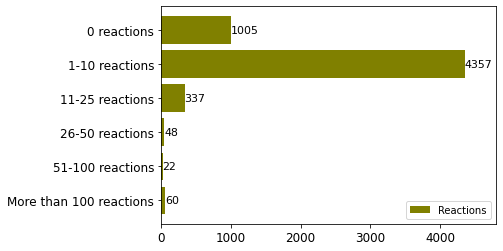

In [58]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, ar_reactions_by_category, label='Reactions', color='olive')
plt.xticks(size=12)
plt.xlim(0, 4800)
plt.yticks(rotation='horizontal', size=12)

for index in range(len(reactions_categories)):
    ax.text(ar_reactions_by_category[index], reactions_categories[index], ar_reactions_by_category[index], rotation='horizontal', va='center', size=11)

plt.legend(loc='lower right')

plt.show()

In [59]:
ar_reactions_over_100_positive = ar_reactions_over_100.loc[(ar_patch['Recommended?'] == True)].count()[0]
ar_reactions_over_100_negative = ar_reactions_over_100.loc[(ar_patch['Recommended?'] == False)].count()[0]
ar_reactions_between_51_and_100_positive = ar_reactions_between_51_and_100.loc[(ar_patch['Recommended?'] == True)].count()[0]
ar_reactions_between_51_and_100_negative = ar_reactions_between_51_and_100.loc[(ar_patch['Recommended?'] == False)].count()[0]
ar_reactions_between_26_and_50_positive = ar_reactions_between_26_and_50.loc[(ar_patch['Recommended?'] == True)].count()[0]
ar_reactions_between_26_and_50_negative = ar_reactions_between_26_and_50.loc[(ar_patch['Recommended?'] == False)].count()[0]
ar_reactions_between_11_and_25_positive = ar_reactions_between_11_and_25.loc[(ar_patch['Recommended?'] == True)].count()[0]
ar_reactions_between_11_and_25_negative = ar_reactions_between_11_and_25.loc[(ar_patch['Recommended?'] == False)].count()[0]
ar_reactions_between_1_and_10_positive = ar_reactions_between_1_and_10.loc[(ar_patch['Recommended?'] == True)].count()[0]
ar_reactions_between_1_and_10_negative = ar_reactions_between_1_and_10.loc[(ar_patch['Recommended?'] == False)].count()[0]
ar_reactions_at_0_positive = ar_reactions_at_0.loc[(ar_patch['Recommended?'] == True)].count()[0]
ar_reactions_at_0_negative = ar_reactions_at_0.loc[(ar_patch['Recommended?'] == False)].count()[0]

ar_reactions_by_category_positive = [
    ar_reactions_over_100_positive,
    ar_reactions_between_51_and_100_positive,
    ar_reactions_between_26_and_50_positive,
    ar_reactions_between_11_and_25_positive,
    ar_reactions_between_1_and_10_positive,
    ar_reactions_at_0_positive
]
ar_reactions_by_category_negative = [
    ar_reactions_over_100_negative,
    ar_reactions_between_51_and_100_negative,
    ar_reactions_between_26_and_50_negative,
    ar_reactions_between_11_and_25_negative,
    ar_reactions_between_1_and_10_negative,
    ar_reactions_at_0_negative
]

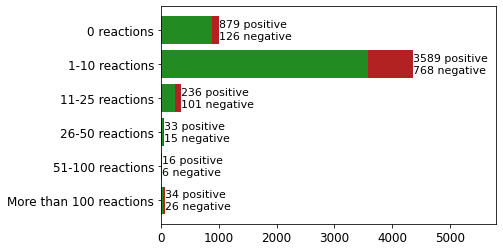

In [60]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, ar_reactions_by_category_positive, color='forestgreen')
plt.barh(reactions_categories, ar_reactions_by_category_negative, left=ar_reactions_by_category_positive, color='firebrick')
plt.xticks(rotation='horizontal', size=12)
plt.xlim(0, 5800)
plt.yticks(size=12)

for index in range(len(reactions_categories)):
    ax.text(ar_reactions_by_category_positive[index]+ar_reactions_by_category_negative[index], reactions_categories[index], f'{ar_reactions_by_category_positive[index]} positive\n{ar_reactions_by_category_negative[index]} negative', ha='left', va='center', size=11)

plt.show()

#### How did the Atlas Rises reviews break down by different time intervals?

In [61]:
ar_week_long_positives = atlas_rises_positives.loc[(atlas_rises_positives['Date'] <= '2017-08-17')].count()[0]
ar_week_long_negatives = atlas_rises_negatives.loc[(atlas_rises_negatives['Date'] <= '2017-08-17')].count()[0]
ar_month_long_positives = atlas_rises_positives.loc[(atlas_rises_positives['Date'] <= '2017-09-11')].count()[0]
ar_month_long_negatives = atlas_rises_negatives.loc[(atlas_rises_negatives['Date'] <= '2017-09-11')].count()[0]
ar_holiday_long_positives = atlas_rises_positives.loc[(atlas_rises_positives['Date'] <= '2017-12-31')].count()[0]
ar_holiday_long_negatives = atlas_rises_negatives.loc[(atlas_rises_negatives['Date'] <= '2017-12-31')].count()[0]

atlas_long_positives = [ar_week_long_positives, ar_month_long_positives, ar_holiday_long_positives]
atlas_long_negatives = [ar_week_long_negatives, ar_month_long_negatives, ar_holiday_long_negatives]

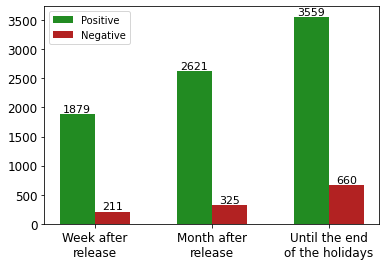

In [62]:
fig, ax = plt.subplots()
holiday_categories = ['Until the end\nof the holidays', 'Month after\nrelease', 'Week after\nrelease']

plt.bar(np.arange(len(atlas_long_positives))-width/2, atlas_long_positives, width, label='Positive', color='forestgreen')
plt.bar(np.arange(len(atlas_long_negatives))+width/2, atlas_long_negatives, width, label='Negative', color='firebrick')
plt.xticks(range(len(holiday_categories)-1,-1,-1), holiday_categories, rotation='horizontal', size=12)
plt.yticks(size=12)

for index in range(len(holiday_categories)):
    ax.text(np.arange(len(atlas_long_positives))[index]-width/2, atlas_long_positives[index], atlas_long_positives[index], ha='center', va='bottom', size=11)
    ax.text(np.arange(len(atlas_long_negatives))[index]+width/2, atlas_long_negatives[index], atlas_long_negatives[index], ha='center', va='bottom', size=11)

plt.legend()

plt.show()

#### How did the Atlas Rises reviews from the most prolific reviewers break down?

In [63]:
ar_prolific_reviews_over_250 = ar_patch.loc[(ar_patch['Total Reviews'] > 250)]
ar_prolific_reviews_over_250_positive = ar_prolific_reviews_over_250.loc[(ar_patch['Recommended?'] == True)].count()[0]
ar_prolific_reviews_over_250_negative = ar_prolific_reviews_over_250.loc[(ar_patch['Recommended?'] == False)].count()[0]

print(f'{ar_prolific_reviews_over_250_positive} positive reviews.')
print(f'{ar_prolific_reviews_over_250_negative} negative reviews.')
print(f'{round(100*ar_prolific_reviews_over_250_positive/ar_prolific_reviews_over_250.count()[0], 2)}% rating.')

16 positive reviews.
7 negative reviews.
69.57% rating.


#### How did the Atlas Rises reviews from slightly less prolific reviewers break down?

In [64]:
ar_prolific_reviews_between_100_and_250 = ar_patch.loc[(ar_patch['Total Reviews'] > 100) & (ar_patch['Total Reviews'] <= 250)]
ar_prolific_reviews_between_100_and_250_positive = ar_prolific_reviews_between_100_and_250.loc[(ar_prolific_reviews_between_100_and_250['Recommended?'] == True)].count()[0]
ar_prolific_reviews_between_100_and_250_negative = ar_prolific_reviews_between_100_and_250.loc[(ar_prolific_reviews_between_100_and_250['Recommended?'] == False)].count()[0]

print(f'{ar_prolific_reviews_between_100_and_250_positive} positive reviews.')
print(f'{ar_prolific_reviews_between_100_and_250_negative} negative reviews.')
print(f'{round(100*ar_prolific_reviews_between_100_and_250_positive/ar_prolific_reviews_between_100_and_250.count()[0], 2)}% rating.')

114 positive reviews.
34 negative reviews.
77.03% rating.


#### How did the Atlas Rises reviews from Steam and non-Steam purchases break down?

In [65]:
ar_steam_purchase_positive = atlas_rises_positives.loc[(atlas_rises_positives['Steam Purchase'] == True)].count()[0]
ar_steam_purchase_negative = atlas_rises_negatives.loc[(atlas_rises_negatives['Steam Purchase'] == True)].count()[0]
ar_nonsteam_purchase_positive = atlas_rises_positives.loc[(atlas_rises_positives['Steam Purchase'] == False)].count()[0]
ar_nonsteam_purchase_negative = atlas_rises_negatives.loc[(atlas_rises_negatives['Steam Purchase'] == False)].count()[0]

ar_steam_nonsteam_breakdown = [ar_steam_purchase_positive, ar_nonsteam_purchase_positive, ar_steam_purchase_negative, ar_nonsteam_purchase_negative]

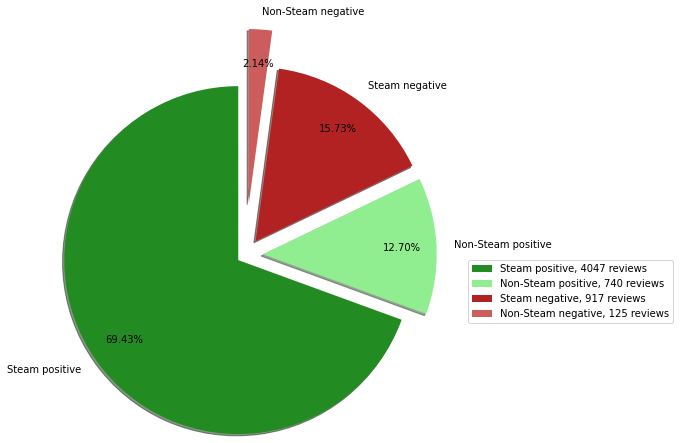

In [66]:
explode = (0.1, 0.2, 0.2, 0.6)

plt.pie(ar_steam_nonsteam_breakdown, labels=steam_review_categories, explode=explode, autopct='%1.2f%%', colors=posi_nega_color_set, shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels=['%s, %1.0f reviews' % (l, s) for l, s in zip(steam_review_categories, ar_steam_nonsteam_breakdown)], bbox_to_anchor=(1.5, 0.5), loc='upper left')

plt.show()

#### How much did the Atlas Rises reviews correlate with staying power?

In [67]:
ar_positive_postreview_time = atlas_rises_positives['Post Review Playing Time']
ar_negative_postreview_time = atlas_rises_negatives['Post Review Playing Time']

print(f'On average, reviewers who rated the game positively played an extra {round(ar_positive_postreview_time.mean())} hours after their review.')
print(f'On average, reviewers who rated the game negatively played an extra {round(ar_negative_postreview_time.mean())} hours after their review.')

On average, reviewers who rated the game positively played an extra 10822 hours after their review.
On average, reviewers who rated the game negatively played an extra 2445 hours after their review.


In [68]:
ar_positive_post_review_time_up_to_half_week = atlas_rises_positives.loc[(atlas_rises_positives['Post Review Playing Time'] < 5040)].count()[0]
ar_positive_post_review_time_up_to_week = atlas_rises_positives.loc[(atlas_rises_positives['Post Review Playing Time'] >= 5040) & (atlas_rises_positives['Post Review Playing Time'] < 10080)].count()[0]
ar_positive_post_review_time_week_more = atlas_rises_positives.loc[(atlas_rises_positives['Post Review Playing Time'] >= 10080)].count()[0]

ar_negative_post_review_time_up_to_half_week = atlas_rises_negatives.loc[(atlas_rises_negatives['Post Review Playing Time'] < 5040)].count()[0]
ar_negative_post_review_time_up_to_week = atlas_rises_negatives.loc[(atlas_rises_negatives['Post Review Playing Time'] >= 5040) & (atlas_rises_negatives['Post Review Playing Time'] < 10080)].count()[0]
ar_negative_post_review_time_week_more = atlas_rises_negatives.loc[(atlas_rises_negatives['Post Review Playing Time'] >= 10080)].count()[0]

ar_positive_data = np.array([100*ar_positive_post_review_time_up_to_half_week/(ar_positive_post_review_time_up_to_half_week+ar_positive_post_review_time_up_to_week+ar_positive_post_review_time_week_more),
                             100*ar_positive_post_review_time_up_to_week/(ar_positive_post_review_time_up_to_half_week+ar_positive_post_review_time_up_to_week+ar_positive_post_review_time_week_more),
                             100*ar_positive_post_review_time_week_more/(ar_positive_post_review_time_up_to_half_week+ar_positive_post_review_time_up_to_week+ar_positive_post_review_time_week_more)])
ar_negative_data = np.array([100*ar_negative_post_review_time_up_to_half_week/(ar_negative_post_review_time_up_to_half_week+ar_negative_post_review_time_up_to_week+ar_negative_post_review_time_week_more),
                             100*ar_negative_post_review_time_up_to_week/(ar_negative_post_review_time_up_to_half_week+ar_negative_post_review_time_up_to_week+ar_negative_post_review_time_week_more),
                             100*ar_negative_post_review_time_week_more/(ar_negative_post_review_time_up_to_half_week+ar_negative_post_review_time_up_to_week+ar_negative_post_review_time_week_more)])

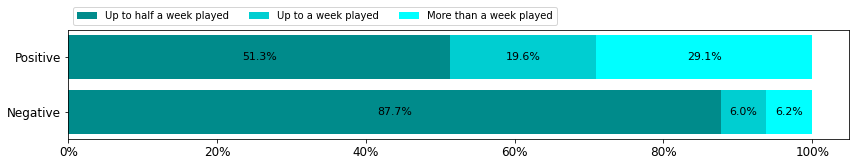

In [69]:
data = np.array(list([ar_positive_data, ar_negative_data]))
data_cum = data.cumsum(axis=1)

fig, ax = plt.subplots(figsize=(14, 2))
ax.invert_yaxis()
plt.xticks(size=12)
plt.yticks(size=12)

for i, (colname, color) in enumerate(zip(post_review_timings, time_color_set)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = ax.barh(keys, widths, left=starts, label=colname, color=color)

    ax.bar_label(rects, fmt='%.1f%%', label_type='center', color='black', size=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.legend(post_review_timings, ncols=len(post_review_timings), bbox_to_anchor=(0, 1), loc='lower left')

plt.show()

### NEXT (Release 1.50)

#### Which NEXT review garnered the most reactions?

In [70]:
next_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-07-24') & (mnsdata_pre_positive['Date'] <= '2018-10-28')]
next_patch_reactions_count = next_patch.loc[(next_patch['Reactions'] == max(next_patch['Reactions']))]['Reactions'].values[0]
next_patch_reactions_review = next_patch.loc[(next_patch['Reactions'] == max(next_patch['Reactions']))]['Reviews'].values[0]
next_patch_reactions_funny = next_patch.loc[(next_patch['Reactions'] == max(next_patch['Reactions']))]['Funny'].values[0]
next_patch_reactions_upvote = next_patch.loc[(next_patch['Reactions'] == max(next_patch['Reactions']))]['Up'].values[0]
next_patch_reactions_date = next_patch.loc[(next_patch['Reactions'] == max(next_patch['Reactions']))]['Date'].values[0]

print(f'{next_patch_reactions_review}')
print(f'---\nSubmitted on {next_patch_reactions_date}, this review garnered {next_patch_reactions_count} reactions ({next_patch_reactions_funny} laughs and {next_patch_reactions_upvote} upvotes).')

Honestly not a bad game. at launch it was a little barren but was still kinda fun to just sail the solar systems, but with aaaall the stuff brought with the updates, now including multiplayer, its easily worth the original pricetag. and if you're mad that you basically got a early access title at supposed "launch", remember that 99% of any other game devs would've chocked it up as a loss and worked on No Man's Sky 2, but these guys actually worked tirelessly for years under extreme scrutiny and prejudice to bring us a game worth our quid, *and they're still updating*. If that doesn't earn back a little respect I truly do not know what would.
---
Submitted on 2018-07-24, this review garnered 11168 reactions (233 laughs and 10935 upvotes).


This was the patch that launched multiplayer! The top review with the most reactions was really positive and defended <b>Hello Games</b> for following through their promise and delivering multiplayer instead of pivoting to another game and abandoning <b>No Man's Sky</b> like many others would have done.

#### How did the NEXT reviews break down by reactions?

In [71]:
next_reactions_over_100 = next_patch.loc[(next_patch['Reactions'] > 100)]
next_reactions_between_51_and_100 = next_patch.loc[(next_patch['Reactions'] > 50) & (next_patch['Reactions'] <= 100)]
next_reactions_between_26_and_50 = next_patch.loc[(next_patch['Reactions'] > 25) & (next_patch['Reactions'] <= 50)]
next_reactions_between_11_and_25 = next_patch.loc[(next_patch['Reactions'] > 10) & (next_patch['Reactions'] <= 25)]
next_reactions_between_1_and_10 = next_patch.loc[(next_patch['Reactions'] >= 1) & (next_patch['Reactions'] <= 10)]
next_reactions_at_0 = next_patch.loc[(next_patch['Reactions'] == 0)]

next_reactions_by_category = [
    next_reactions_over_100.count()[0],
    next_reactions_between_51_and_100.count()[0],
    next_reactions_between_26_and_50.count()[0],
    next_reactions_between_11_and_25.count()[0],
    next_reactions_between_1_and_10.count()[0],
    next_reactions_at_0.count()[0]
]

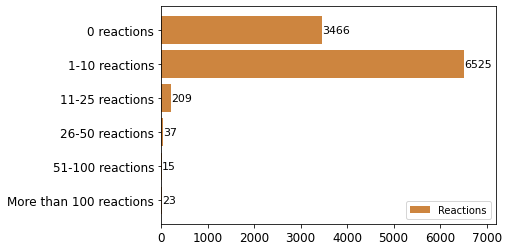

In [72]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, next_reactions_by_category, label='Reactions', color='peru')
plt.xticks(size=12)
plt.xlim(0, 7200)
plt.yticks(rotation='horizontal', size=12)

for index in range(len(reactions_categories)):
    ax.text(next_reactions_by_category[index], reactions_categories[index], next_reactions_by_category[index], rotation='horizontal', va='center', size=11)

plt.legend(loc='lower right')

plt.show()

In [73]:
next_reactions_over_100_positive = next_reactions_over_100.loc[(next_patch['Recommended?'] == True)].count()[0]
next_reactions_over_100_negative = next_reactions_over_100.loc[(next_patch['Recommended?'] == False)].count()[0]
next_reactions_between_51_and_100_positive = next_reactions_between_51_and_100.loc[(next_patch['Recommended?'] == True)].count()[0]
next_reactions_between_51_and_100_negative = next_reactions_between_51_and_100.loc[(next_patch['Recommended?'] == False)].count()[0]
next_reactions_between_26_and_50_positive = next_reactions_between_26_and_50.loc[(next_patch['Recommended?'] == True)].count()[0]
next_reactions_between_26_and_50_negative = next_reactions_between_26_and_50.loc[(next_patch['Recommended?'] == False)].count()[0]
next_reactions_between_11_and_25_positive = next_reactions_between_11_and_25.loc[(next_patch['Recommended?'] == True)].count()[0]
next_reactions_between_11_and_25_negative = next_reactions_between_11_and_25.loc[(next_patch['Recommended?'] == False)].count()[0]
next_reactions_between_1_and_10_positive = next_reactions_between_1_and_10.loc[(next_patch['Recommended?'] == True)].count()[0]
next_reactions_between_1_and_10_negative = next_reactions_between_1_and_10.loc[(next_patch['Recommended?'] == False)].count()[0]
next_reactions_at_0_positive = next_reactions_at_0.loc[(next_patch['Recommended?'] == True)].count()[0]
next_reactions_at_0_negative = next_reactions_at_0.loc[(next_patch['Recommended?'] == False)].count()[0]

next_reactions_by_category_positive = [
    next_reactions_over_100_positive,
    next_reactions_between_51_and_100_positive,
    next_reactions_between_26_and_50_positive,
    next_reactions_between_11_and_25_positive,
    next_reactions_between_1_and_10_positive,
    next_reactions_at_0_positive
]
next_reactions_by_category_negative = [
    next_reactions_over_100_negative,
    next_reactions_between_51_and_100_negative,
    next_reactions_between_26_and_50_negative,
    next_reactions_between_11_and_25_negative,
    next_reactions_between_1_and_10_negative, next_reactions_at_0_negative
]

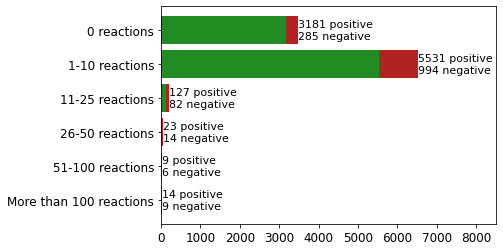

In [74]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, next_reactions_by_category_positive, color='forestgreen')
plt.barh(reactions_categories, next_reactions_by_category_negative, left=next_reactions_by_category_positive, color='firebrick')
plt.xticks(rotation='horizontal', size=12)
plt.xlim(0, 8500)
plt.yticks(size=12)

for index in range(len(reactions_categories)):
    ax.text(next_reactions_by_category_positive[index]+next_reactions_by_category_negative[index], reactions_categories[index], f'{next_reactions_by_category_positive[index]} positive\n{next_reactions_by_category_negative[index]} negative', ha='left', va='center', size=11)

plt.show()

#### How did the NEXT reviews break down by different time intervals?

In [75]:
next_day_long_positives = next_positives.loc[(next_positives['Date'] == '2018-07-24')].count()[0]
next_day_long_negatives = next_negatives.loc[(next_negatives['Date'] == '2018-07-24')].count()[0]
next_week_long_positives = next_positives.loc[(next_positives['Date'] <= '2018-07-30')].count()[0]
next_week_long_negatives = next_negatives.loc[(next_negatives['Date'] <= '2018-07-30')].count()[0]
next_month_long_positives = next_positives.loc[(next_positives['Date'] <= '2018-08-24')].count()[0]
next_month_long_negatives = next_negatives.loc[(next_negatives['Date'] <= '2018-08-24')].count()[0]

next_long_positives = [next_day_long_positives, next_week_long_positives, next_month_long_positives]
next_long_negatives = [next_day_long_negatives, next_week_long_negatives, next_month_long_negatives]

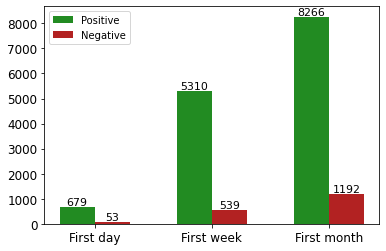

In [76]:
fig, ax = plt.subplots()
width = 0.3

plt.bar(np.arange(len(next_long_positives))-width/2, next_long_positives, width, label='Positive', color='forestgreen')
plt.bar(np.arange(len(next_long_negatives))+width/2, next_long_negatives, width, label='Negative', color='firebrick')
plt.xticks(range(len(first_categories)-1,-1,-1), first_categories, rotation='horizontal', size=12)
plt.yticks(size=12)

for index in range(len(first_categories)):
    ax.text(np.arange(len(next_long_positives))[index]-width/2, next_long_positives[index], next_long_positives[index], ha='center', va='bottom', size=11)
    ax.text(np.arange(len(next_long_negatives))[index]+width/2, next_long_negatives[index], next_long_negatives[index], ha='center', va='bottom', size=11)

plt.legend()

plt.show()

#### How did the NEXT reviews from the most prolific reviewers break down?

In [77]:
next_prolific_reviews_over_250 = next_patch.loc[(next_patch['Total Reviews'] > 250)]
next_prolific_reviews_over_250_positive = next_prolific_reviews_over_250.loc[(next_patch['Recommended?'] == True)].count()[0]
next_prolific_reviews_over_250_negative = next_prolific_reviews_over_250.loc[(next_patch['Recommended?'] == False)].count()[0]

print(f'{next_prolific_reviews_over_250_positive} positive reviews.')
print(f'{next_prolific_reviews_over_250_negative} negative reviews.')
print(f'{round(100*next_prolific_reviews_over_250_positive/next_prolific_reviews_over_250.count()[0], 2)}% rating.')

39 positive reviews.
11 negative reviews.
78.0% rating.


#### How did the NEXT reviews from slightly less prolific reviewers break down?

In [78]:
next_prolific_reviews_between_100_and_250 = next_patch.loc[(next_patch['Total Reviews'] > 100) & (next_patch['Total Reviews'] <= 250)]
next_prolific_reviews_between_100_and_250_positive = next_prolific_reviews_between_100_and_250.loc[(next_prolific_reviews_between_100_and_250['Recommended?'] == True)].count()[0]
next_prolific_reviews_between_100_and_250_negative = next_prolific_reviews_between_100_and_250.loc[(next_prolific_reviews_between_100_and_250['Recommended?'] == False)].count()[0]

print(f'{next_prolific_reviews_between_100_and_250_positive} positive reviews.')
print(f'{next_prolific_reviews_between_100_and_250_negative} negative reviews.')
print(f'{round(100*next_prolific_reviews_between_100_and_250_positive/next_prolific_reviews_between_100_and_250.count()[0], 2)}% rating.')

293 positive reviews.
47 negative reviews.
86.18% rating.


#### How did the NEXT reviews from Steam and non-Steam purchases break down?

In [79]:
next_steam_purchase_positive = next_positives.loc[(next_positives['Steam Purchase'] == True)].count()[0]
next_steam_purchase_negative = next_negatives.loc[(next_negatives['Steam Purchase'] == True)].count()[0]
next_nonsteam_purchase_positive = next_positives.loc[(next_positives['Steam Purchase'] == False)].count()[0]
next_nonsteam_purchase_negative = next_negatives.loc[(next_negatives['Steam Purchase'] == False)].count()[0]

next_steam_nonsteam_breakdown = [next_steam_purchase_positive, next_nonsteam_purchase_positive, next_steam_purchase_negative, next_nonsteam_purchase_negative]

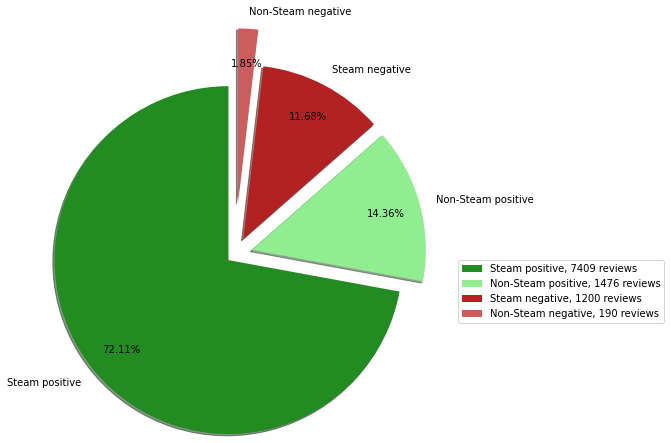

In [80]:
explode = (0.1, 0.2, 0.2, 0.6)

plt.pie(next_steam_nonsteam_breakdown, labels=steam_review_categories, explode=explode, autopct='%1.2f%%', colors=posi_nega_color_set, shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels=['%s, %1.0f reviews' % (l, s) for l, s in zip(steam_review_categories, next_steam_nonsteam_breakdown)], bbox_to_anchor=(1.5, 0.5), loc='upper left')

plt.show()

#### How much did the NEXT reviews correlate with staying power?

In [81]:
next_positive_postreview_time = next_positives['Post Review Playing Time']
next_negative_postreview_time = next_negatives['Post Review Playing Time']

print(f'On average, reviewers who rated the game positively played an extra {round(next_positive_postreview_time.mean())} hours after their review.')
print(f'On average, reviewers who rated the game negatively played an extra {round(next_negative_postreview_time.mean())} hours after their review.')

On average, reviewers who rated the game positively played an extra 7329 hours after their review.
On average, reviewers who rated the game negatively played an extra 3168 hours after their review.


In [82]:
next_positive_post_review_time_up_to_half_week = next_positives.loc[(next_positives['Post Review Playing Time'] < 5040)].count()[0]
next_positive_post_review_time_up_to_week = next_positives.loc[(next_positives['Post Review Playing Time'] >= 5040) & (next_positives['Post Review Playing Time'] < 10080)].count()[0]
next_positive_post_review_time_week_more = next_positives.loc[(next_positives['Post Review Playing Time'] >= 10080)].count()[0]

next_negative_post_review_time_up_to_half_week = next_negatives.loc[(next_negatives['Post Review Playing Time'] < 5040)].count()[0]
next_negative_post_review_time_up_to_week = next_negatives.loc[(next_negatives['Post Review Playing Time'] >= 5040) & (next_negatives['Post Review Playing Time'] < 10080)].count()[0]
next_negative_post_review_time_week_more = next_negatives.loc[(next_negatives['Post Review Playing Time'] >= 10080)].count()[0]

next_positive_data = np.array([100*next_positive_post_review_time_up_to_half_week/(next_positive_post_review_time_up_to_half_week+next_positive_post_review_time_up_to_week+next_positive_post_review_time_week_more),
                               100*next_positive_post_review_time_up_to_week/(next_positive_post_review_time_up_to_half_week+next_positive_post_review_time_up_to_week+next_positive_post_review_time_week_more),
                               100*next_positive_post_review_time_week_more/(next_positive_post_review_time_up_to_half_week+next_positive_post_review_time_up_to_week+next_positive_post_review_time_week_more)])
next_negative_data = np.array([100*next_negative_post_review_time_up_to_half_week/(next_negative_post_review_time_up_to_half_week+next_negative_post_review_time_up_to_week+next_negative_post_review_time_week_more),
                               100*next_negative_post_review_time_up_to_week/(next_negative_post_review_time_up_to_half_week+next_negative_post_review_time_up_to_week+next_negative_post_review_time_week_more),
                               100*next_negative_post_review_time_week_more/(next_negative_post_review_time_up_to_half_week+next_negative_post_review_time_up_to_week+next_negative_post_review_time_week_more)])

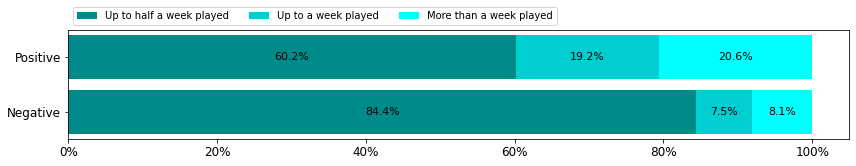

In [83]:
data = np.array(list([next_positive_data, next_negative_data]))
data_cum = data.cumsum(axis=1)

fig, ax = plt.subplots(figsize=(14, 2))
ax.invert_yaxis()
plt.xticks(size=12)
plt.yticks(size=12)

for i, (colname, color) in enumerate(zip(post_review_timings, time_color_set)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = ax.barh(keys, widths, left=starts, label=colname, color=color)

    ax.bar_label(rects, fmt='%.1f%%', label_type='center', color='black', size=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.legend(post_review_timings, ncols=len(post_review_timings), bbox_to_anchor=(0, 1), loc='lower left')

plt.show()

### Beyond (Release 2.00)

#### Which Beyond review garnered the most reactions?

In [84]:
beyond_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2019-08-14') & (mnsdata_pre_positive['Date'] <= '2019-11-27')]
beyond_patch_reactions_count = beyond_patch.loc[(beyond_patch['Reactions'] == max(beyond_patch['Reactions']))]['Reactions'].values[0]
beyond_patch_reactions_review = beyond_patch.loc[(beyond_patch['Reactions'] == max(beyond_patch['Reactions']))]['Reviews'].values[0]
beyond_patch_reactions_funny = beyond_patch.loc[(beyond_patch['Reactions'] == max(beyond_patch['Reactions']))]['Funny'].values[0]
beyond_patch_reactions_upvote = beyond_patch.loc[(beyond_patch['Reactions'] == max(beyond_patch['Reactions']))]['Up'].values[0]
beyond_patch_reactions_date = beyond_patch.loc[(beyond_patch['Reactions'] == max(beyond_patch['Reactions']))]['Date'].values[0]

print(f'{beyond_patch_reactions_review}')
print(f'---\nSubmitted on {beyond_patch_reactions_date}, this review garnered {beyond_patch_reactions_count} reactions ({beyond_patch_reactions_funny} laughs and {beyond_patch_reactions_upvote} upvotes).')

I played this game for 23 hours, and I did not have fun.

Some will say "You must have been having fun, otherwise you wouldn't have played it for 23 hours. Why didn't you stop after 5 hours?"

The answer to that is: Because I BELIEVED it would get better. I had faith. People kept saying things like this:

"Planets get more interesting closer to the center."
"You just haven't given the game enough time yet. It gets better once you get more inventory slots."
"Keep playing, I've had an amazing time."

Lets say someone came to me and said "Lets dig to the center of the Earth. Theres a pot of gold there and you will be rich. Heres a shovel", and I start digging. After 10 hours I say "This sucks. I'm going back up the ladder."

The gentleman says "No keep digging. It will get better. It will be worth it."

After 23 hours of digging I'm still having a terrible time. Do I give up and say "that was no fun", or do I keep digging?

How about if I had paid 40 quid for the shovel?

edit: I wrote th

Another reviewer who definitely played the game, left, and came back to give it another chance. He/she did not enjoy it even with multiplayer and VR updates, but at least he/she tried, and that is probably all <b>Hello Games</b> could ever ask for.

#### How did the Beyond reviews break down by reactions?

In [85]:
beyond_reactions_over_100 = beyond_patch.loc[(beyond_patch['Reactions'] > 100)]
beyond_reactions_between_51_and_100 = beyond_patch.loc[(beyond_patch['Reactions'] > 50) & (beyond_patch['Reactions'] <= 100)]
beyond_reactions_between_26_and_50 = beyond_patch.loc[(beyond_patch['Reactions'] > 25) & (beyond_patch['Reactions'] <= 50)]
beyond_reactions_between_11_and_25 = beyond_patch.loc[(beyond_patch['Reactions'] > 10) & (beyond_patch['Reactions'] <= 25)]
beyond_reactions_between_1_and_10 = beyond_patch.loc[(beyond_patch['Reactions'] >= 1) & (beyond_patch['Reactions'] <= 10)]
beyond_reactions_at_0 = beyond_patch.loc[(beyond_patch['Reactions'] == 0)]

beyond_reactions_by_category = [
    beyond_reactions_over_100.count()[0],
    beyond_reactions_between_51_and_100.count()[0],
    beyond_reactions_between_26_and_50.count()[0],
    beyond_reactions_between_11_and_25.count()[0],
    beyond_reactions_between_1_and_10.count()[0],
    beyond_reactions_at_0.count()[0]
]

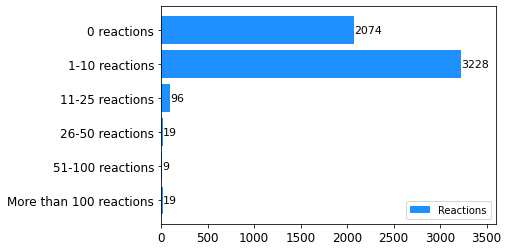

In [86]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, beyond_reactions_by_category, label='Reactions', color='dodgerblue')
plt.xticks(size=12)
plt.xlim(0, 3600)
plt.yticks(rotation='horizontal', size=12)

for index in range(len(reactions_categories)):
    ax.text(beyond_reactions_by_category[index], reactions_categories[index], beyond_reactions_by_category[index], rotation='horizontal', va='center', size=11)

plt.legend(loc='lower right')

plt.show()

In [87]:
beyond_reactions_over_100_positive = beyond_reactions_over_100.loc[(beyond_patch['Recommended?'] == True)].count()[0]
beyond_reactions_over_100_negative = beyond_reactions_over_100.loc[(beyond_patch['Recommended?'] == False)].count()[0]
beyond_reactions_between_51_and_100_positive = beyond_reactions_between_51_and_100.loc[(beyond_patch['Recommended?'] == True)].count()[0]
beyond_reactions_between_51_and_100_negative = beyond_reactions_between_51_and_100.loc[(beyond_patch['Recommended?'] == False)].count()[0]
beyond_reactions_between_26_and_50_positive = beyond_reactions_between_26_and_50.loc[(beyond_patch['Recommended?'] == True)].count()[0]
beyond_reactions_between_26_and_50_negative = beyond_reactions_between_26_and_50.loc[(beyond_patch['Recommended?'] == False)].count()[0]
beyond_reactions_between_11_and_25_positive = beyond_reactions_between_11_and_25.loc[(beyond_patch['Recommended?'] == True)].count()[0]
beyond_reactions_between_11_and_25_negative = beyond_reactions_between_11_and_25.loc[(beyond_patch['Recommended?'] == False)].count()[0]
beyond_reactions_between_1_and_10_positive = beyond_reactions_between_1_and_10.loc[(beyond_patch['Recommended?'] == True)].count()[0]
beyond_reactions_between_1_and_10_negative = beyond_reactions_between_1_and_10.loc[(beyond_patch['Recommended?'] == False)].count()[0]
beyond_reactions_at_0_positive = beyond_reactions_at_0.loc[(beyond_patch['Recommended?'] == True)].count()[0]
beyond_reactions_at_0_negative = beyond_reactions_at_0.loc[(beyond_patch['Recommended?'] == False)].count()[0]

beyond_reactions_by_category_positive = [
    beyond_reactions_over_100_positive,
    beyond_reactions_between_51_and_100_positive,
    beyond_reactions_between_26_and_50_positive,
    beyond_reactions_between_11_and_25_positive,
    beyond_reactions_between_1_and_10_positive,
    beyond_reactions_at_0_positive
]
beyond_reactions_by_category_negative = [
    beyond_reactions_over_100_negative,
    beyond_reactions_between_51_and_100_negative,
    beyond_reactions_between_26_and_50_negative,
    beyond_reactions_between_11_and_25_negative,
    beyond_reactions_between_1_and_10_negative,
    beyond_reactions_at_0_negative
]

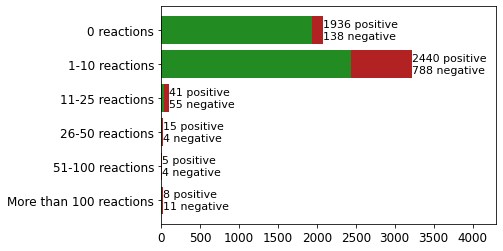

In [88]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, beyond_reactions_by_category_positive, color='forestgreen')
plt.barh(reactions_categories, beyond_reactions_by_category_negative, left=beyond_reactions_by_category_positive, color='firebrick')
plt.xticks(rotation='horizontal', size=12)
plt.xlim(0, 4300)
plt.yticks(size=12)

for index in range(len(reactions_categories)):
    ax.text(beyond_reactions_by_category_positive[index]+beyond_reactions_by_category_negative[index], reactions_categories[index], f'{beyond_reactions_by_category_positive[index]} positive\n{beyond_reactions_by_category_negative[index]} negative', ha='left', va='center', size=11)

plt.show()

#### How did the Beyond reviews break down by different time intervals?

In [89]:
beyond_day_long_positives = beyond_positives.loc[(beyond_positives['Date'] == '2019-08-14')].count()[0]
beyond_day_long_negatives = beyond_negatives.loc[(beyond_negatives['Date'] == '2019-08-14')].count()[0]
beyond_week_long_positives = beyond_positives.loc[(beyond_positives['Date'] <= '2019-08-20')].count()[0]
beyond_week_long_negatives = beyond_negatives.loc[(beyond_negatives['Date'] <= '2019-08-20')].count()[0]
beyond_month_long_positives = beyond_positives.loc[(beyond_positives['Date'] <= '2019-09-14')].count()[0]
beyond_month_long_negatives = beyond_negatives.loc[(beyond_negatives['Date'] <= '2019-09-14')].count()[0]

beyond_long_positives = [beyond_day_long_positives, beyond_week_long_positives, beyond_month_long_positives]
beyond_long_negatives = [beyond_day_long_negatives, beyond_week_long_negatives, beyond_month_long_negatives]

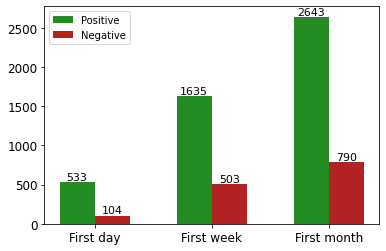

In [90]:
fig, ax = plt.subplots()
width = 0.3

plt.bar(np.arange(len(beyond_long_positives))-width/2, beyond_long_positives, width, label='Positive', color='forestgreen')
plt.bar(np.arange(len(beyond_long_negatives))+width/2, beyond_long_negatives, width, label='Negative', color='firebrick')
plt.xticks(range(len(first_categories)-1,-1,-1), first_categories, rotation='horizontal', size=12)
plt.yticks(size=12)

for index in range(len(first_categories)):
    ax.text(np.arange(len(beyond_long_positives))[index]-width/2, beyond_long_positives[index], beyond_long_positives[index], ha='center', va='bottom', size=11)
    ax.text(np.arange(len(beyond_long_negatives))[index]+width/2, beyond_long_negatives[index], beyond_long_negatives[index], ha='center', va='bottom', size=11)

plt.legend()

plt.show()

#### How did the Beyond reviews from the most prolific reviewers break down?

In [91]:
beyond_prolific_reviews_over_250 = beyond_patch.loc[(beyond_patch['Total Reviews'] > 250)]
beyond_prolific_reviews_over_250_positive = beyond_prolific_reviews_over_250.loc[(beyond_patch['Recommended?'] == True)].count()[0]
beyond_prolific_reviews_over_250_negative = beyond_prolific_reviews_over_250.loc[(beyond_patch['Recommended?'] == False)].count()[0]

print(f'{beyond_prolific_reviews_over_250_positive} positive reviews.')
print(f'{beyond_prolific_reviews_over_250_negative} negative reviews.')
print(f'{round(100*beyond_prolific_reviews_over_250_positive/beyond_prolific_reviews_over_250.count()[0], 2)}% rating.')

21 positive reviews.
8 negative reviews.
72.41% rating.


#### How did the Beyond reviews from slightly less prolific reviewers break down?

In [92]:
beyond_prolific_reviews_between_100_and_250 = beyond_patch.loc[(beyond_patch['Total Reviews'] > 100) & (beyond_patch['Total Reviews'] <= 500)]
beyond_prolific_reviews_between_100_and_250_positive = beyond_prolific_reviews_between_100_and_250.loc[(beyond_prolific_reviews_between_100_and_250['Recommended?'] == True)].count()[0]
beyond_prolific_reviews_between_100_and_250_negative = beyond_prolific_reviews_between_100_and_250.loc[(beyond_prolific_reviews_between_100_and_250['Recommended?'] == False)].count()[0]

print(f'{beyond_prolific_reviews_between_100_and_250_positive} positive reviews.')
print(f'{beyond_prolific_reviews_between_100_and_250_negative} negative reviews.')
print(f'{round(100*beyond_prolific_reviews_between_100_and_250_positive/beyond_prolific_reviews_between_100_and_250.count()[0], 2)}% rating.')

176 positive reviews.
55 negative reviews.
76.19% rating.


#### How did the Beyond reviews from Steam and non-Steam purchases break down?

In [93]:
beyond_steam_purchase_positive = beyond_positives.loc[(beyond_positives['Steam Purchase'] == True)].count()[0]
beyond_steam_purchase_negative = beyond_negatives.loc[(beyond_negatives['Steam Purchase'] == True)].count()[0]
beyond_nonsteam_purchase_positive = beyond_positives.loc[(beyond_positives['Steam Purchase'] == False)].count()[0]
beyond_nonsteam_purchase_negative = beyond_negatives.loc[(beyond_negatives['Steam Purchase'] == False)].count()[0]

beyond_steam_nonsteam_breakdown = [beyond_steam_purchase_positive, beyond_nonsteam_purchase_positive, beyond_steam_purchase_negative, beyond_nonsteam_purchase_negative]

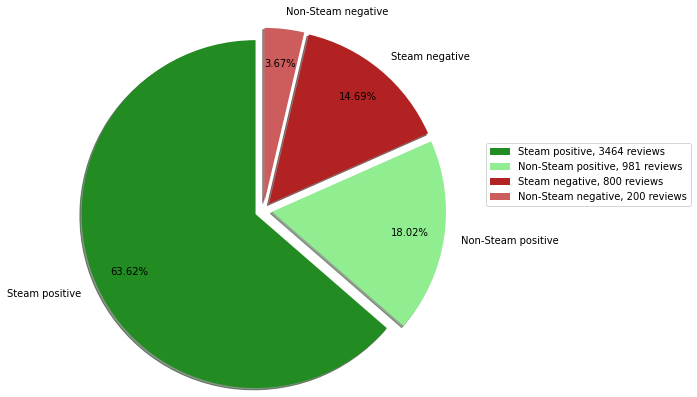

In [94]:
explode = (0.1, 0.1, 0.1, 0.1)

plt.pie(beyond_steam_nonsteam_breakdown, labels=steam_review_categories, explode=explode, autopct='%1.2f%%', colors=posi_nega_color_set, shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels=['%s, %1.0f reviews' % (l, s) for l, s in zip(steam_review_categories, beyond_steam_nonsteam_breakdown)], bbox_to_anchor=(1.5, 0.5), loc='lower left')

plt.show()

#### How much did the Beyond reviews correlate with staying power?

In [95]:
beyond_positive_postreview_time = beyond_positives['Post Review Playing Time']
beyond_negative_postreview_time = beyond_negatives['Post Review Playing Time']

print(f'On average, reviewers who rated the game positively played an extra {round(beyond_positive_postreview_time.mean())} hours after their review.')
print(f'On average, reviewers who rated the game negatively played an extra {round(beyond_negative_postreview_time.mean())} hours after their review.')

On average, reviewers who rated the game positively played an extra 11825 hours after their review.
On average, reviewers who rated the game negatively played an extra 3709 hours after their review.


In [96]:
beyond_positive_post_review_time_up_to_half_week = beyond_positives.loc[(beyond_positives['Post Review Playing Time'] < 5040)].count()[0]
beyond_positive_post_review_time_up_to_week = beyond_positives.loc[(beyond_positives['Post Review Playing Time'] >= 5040) & (beyond_positives['Post Review Playing Time'] < 10080)].count()[0]
beyond_positive_post_review_time_week_more = beyond_positives.loc[(beyond_positives['Post Review Playing Time'] >= 10080)].count()[0]

beyond_negative_post_review_time_up_to_half_week = beyond_negatives.loc[(beyond_negatives['Post Review Playing Time'] < 5040)].count()[0]
beyond_negative_post_review_time_up_to_week = beyond_negatives.loc[(beyond_negatives['Post Review Playing Time'] >= 5040) & (beyond_negatives['Post Review Playing Time'] < 10080)].count()[0]
beyond_negative_post_review_time_week_more = beyond_negatives.loc[(beyond_negatives['Post Review Playing Time'] >= 10080)].count()[0]

beyond_positive_data = np.array([100*beyond_positive_post_review_time_up_to_half_week/(beyond_positive_post_review_time_up_to_half_week+beyond_positive_post_review_time_up_to_week+beyond_positive_post_review_time_week_more),
                                 100*beyond_positive_post_review_time_up_to_week/(beyond_positive_post_review_time_up_to_half_week+beyond_positive_post_review_time_up_to_week+beyond_positive_post_review_time_week_more),
                                 100*beyond_positive_post_review_time_week_more/(beyond_positive_post_review_time_up_to_half_week+beyond_positive_post_review_time_up_to_week+beyond_positive_post_review_time_week_more)])
beyond_negative_data = np.array([100*beyond_negative_post_review_time_up_to_half_week/(beyond_negative_post_review_time_up_to_half_week+beyond_negative_post_review_time_up_to_week+beyond_negative_post_review_time_week_more),
                                 100*beyond_negative_post_review_time_up_to_week/(beyond_negative_post_review_time_up_to_half_week+beyond_negative_post_review_time_up_to_week+beyond_negative_post_review_time_week_more),
                                 100*beyond_negative_post_review_time_week_more/(beyond_negative_post_review_time_up_to_half_week+beyond_negative_post_review_time_up_to_week+beyond_negative_post_review_time_week_more)])

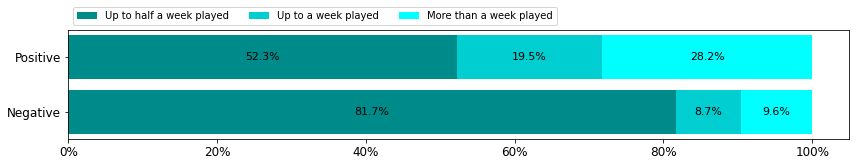

In [97]:
data = np.array(list([beyond_positive_data, beyond_negative_data]))
data_cum = data.cumsum(axis=1)

fig, ax = plt.subplots(figsize=(14, 2))
ax.invert_yaxis()
plt.xticks(size=12)
plt.yticks(size=12)

for i, (colname, color) in enumerate(zip(post_review_timings, time_color_set)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = ax.barh(keys, widths, left=starts, label=colname, color=color)

    ax.bar_label(rects, fmt='%.1f%%', label_type='center', color='black', size=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.legend(post_review_timings, ncols=len(post_review_timings), bbox_to_anchor=(0, 1), loc='lower left')

plt.show()

### Next Generation (Release 3.10)

#### Which Next Generation review garnered the most reactions?

In [98]:
next_gen_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-11-20') & (mnsdata_pre_positive['Date'] <= '2021-02-16')]
next_gen_patch_reactions_count = next_gen_patch.loc[(next_gen_patch['Reactions'] == max(next_gen_patch['Reactions']))]['Reactions'].values[0]
next_gen_patch_reactions_review = next_gen_patch.loc[(next_gen_patch['Reactions'] == max(next_gen_patch['Reactions']))]['Reviews'].values[0]
next_gen_patch_reactions_funny = next_gen_patch.loc[(next_gen_patch['Reactions'] == max(next_gen_patch['Reactions']))]['Funny'].values[0]
next_gen_patch_reactions_upvote = next_gen_patch.loc[(next_gen_patch['Reactions'] == max(next_gen_patch['Reactions']))]['Up'].values[0]
next_gen_patch_reactions_date = next_gen_patch.loc[(next_gen_patch['Reactions'] == max(next_gen_patch['Reactions']))]['Date'].values[0]

print(f'{next_gen_patch_reactions_review.strip()}')
print(f'---\nSubmitted on {next_gen_patch_reactions_date}, this review garnered {next_gen_patch_reactions_count} reactions ({next_gen_patch_reactions_funny} laughs and {next_gen_patch_reactions_upvote} upvotes).')

One of the greatest redemption arcs in video gaming.
---
Submitted on 2020-11-26, this review garnered 3003 reactions (147 laughs and 2856 upvotes).


#### How did the Next Generation reviews break down by reactions?

In [99]:
next_gen_reactions_over_100 = next_gen_patch.loc[(next_gen_patch['Reactions'] > 100)]
next_gen_reactions_between_51_and_100 = next_gen_patch.loc[(next_gen_patch['Reactions'] > 50) & (next_gen_patch['Reactions'] <= 100)]
next_gen_reactions_between_26_and_50 = next_gen_patch.loc[(next_gen_patch['Reactions'] > 25) & (next_gen_patch['Reactions'] <= 50)]
next_gen_reactions_between_11_and_25 = next_gen_patch.loc[(next_gen_patch['Reactions'] > 10) & (next_gen_patch['Reactions'] <= 25)]
next_gen_reactions_between_1_and_10 = next_gen_patch.loc[(next_gen_patch['Reactions'] >= 1) & (next_gen_patch['Reactions'] <= 10)]
next_gen_reactions_at_0 = next_gen_patch.loc[(next_gen_patch['Reactions'] == 0)]

next_gen_reactions_by_category = [
    next_gen_reactions_over_100.count()[0],
    next_gen_reactions_between_51_and_100.count()[0],
    next_gen_reactions_between_26_and_50.count()[0],
    next_gen_reactions_between_11_and_25.count()[0],
    next_gen_reactions_between_1_and_10.count()[0],
    next_gen_reactions_at_0.count()[0]
]

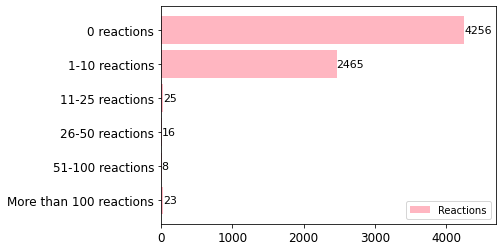

In [100]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, next_gen_reactions_by_category, label='Reactions', color='lightpink')
plt.xticks(size=12)
plt.xlim(0, 4700)
plt.yticks(rotation='horizontal', size=12)

for index in range(len(reactions_categories)):
    ax.text(next_gen_reactions_by_category[index], reactions_categories[index], next_gen_reactions_by_category[index], rotation='horizontal', va='center', size=11)

plt.legend(loc='lower right')

plt.show()

In [101]:
next_gen_reactions_over_100_positive = next_gen_reactions_over_100.loc[(next_gen_patch['Recommended?'] == True)].count()[0]
next_gen_reactions_over_100_negative = next_gen_reactions_over_100.loc[(next_gen_patch['Recommended?'] == False)].count()[0]
next_gen_reactions_between_51_and_100_positive = next_gen_reactions_between_51_and_100.loc[(next_gen_patch['Recommended?'] == True)].count()[0]
next_gen_reactions_between_51_and_100_negative = next_gen_reactions_between_51_and_100.loc[(next_gen_patch['Recommended?'] == False)].count()[0]
next_gen_reactions_between_26_and_50_positive = next_gen_reactions_between_26_and_50.loc[(next_gen_patch['Recommended?'] == True)].count()[0]
next_gen_reactions_between_26_and_50_negative = next_gen_reactions_between_26_and_50.loc[(next_gen_patch['Recommended?'] == False)].count()[0]
next_gen_reactions_between_11_and_25_positive = next_gen_reactions_between_11_and_25.loc[(next_gen_patch['Recommended?'] == True)].count()[0]
next_gen_reactions_between_11_and_25_negative = next_gen_reactions_between_11_and_25.loc[(next_gen_patch['Recommended?'] == False)].count()[0]
next_gen_reactions_between_1_and_10_positive = next_gen_reactions_between_1_and_10.loc[(next_gen_patch['Recommended?'] == True)].count()[0]
next_gen_reactions_between_1_and_10_negative = next_gen_reactions_between_1_and_10.loc[(next_gen_patch['Recommended?'] == False)].count()[0]
next_gen_reactions_at_0_positive = next_gen_reactions_at_0.loc[(next_gen_patch['Recommended?'] == True)].count()[0]
next_gen_reactions_at_0_negative = next_gen_reactions_at_0.loc[(next_gen_patch['Recommended?'] == False)].count()[0]

next_gen_reactions_by_category_positive = [
    next_gen_reactions_over_100_positive,
    next_gen_reactions_between_51_and_100_positive,
    next_gen_reactions_between_26_and_50_positive,
    next_gen_reactions_between_11_and_25_positive,
    next_gen_reactions_between_1_and_10_positive,
    next_gen_reactions_at_0_positive
]
next_gen_reactions_by_category_negative = [
    next_gen_reactions_over_100_negative,
    next_gen_reactions_between_51_and_100_negative,
    next_gen_reactions_between_26_and_50_negative,
    next_gen_reactions_between_11_and_25_negative,
    next_gen_reactions_between_1_and_10_negative,
    next_gen_reactions_at_0_negative
]

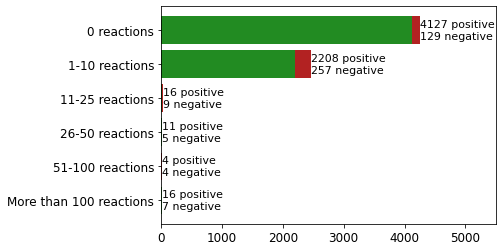

In [102]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, next_gen_reactions_by_category_positive, color='forestgreen')
plt.barh(reactions_categories, next_gen_reactions_by_category_negative, left=next_gen_reactions_by_category_positive, color='firebrick')
plt.xticks(rotation='horizontal', size=12)
plt.xlim(0, 5500)
plt.yticks(size=12)

for index in range(len(reactions_categories)):
    ax.text(next_gen_reactions_by_category_positive[index]+next_gen_reactions_by_category_negative[index], reactions_categories[index], f'{next_gen_reactions_by_category_positive[index]} positive\n{next_gen_reactions_by_category_negative[index]} negative', ha='left', va='center', size=11)

plt.show()

#### How did the Next Generation reviews break down by different time intervals?

In [103]:
next_gen_week_long_positives = next_gen_positives.loc[(next_gen_positives['Date'] <= '2020-11-16')].count()[0]
next_gen_week_long_negatives = next_gen_negatives.loc[(next_gen_negatives['Date'] <= '2020-11-16')].count()[0]
next_gen_month_long_positives = next_gen_positives.loc[(next_gen_positives['Date'] <= '2020-12-10')].count()[0]
next_gen_month_long_negatives = next_gen_negatives.loc[(next_gen_negatives['Date'] <= '2020-12-10')].count()[0]
next_gen_holiday_long_positives = next_gen_positives.loc[(next_gen_positives['Date'] <= '2021-01-03')].count()[0]
next_gen_holiday_long_negatives = next_gen_negatives.loc[(next_gen_negatives['Date'] <= '2021-01-03')].count()[0]

next_generation_positives = [next_gen_week_long_positives, next_gen_month_long_positives, next_gen_holiday_long_positives]
next_generation_negatives = [next_gen_week_long_negatives, next_gen_month_long_negatives, next_gen_holiday_long_negatives]

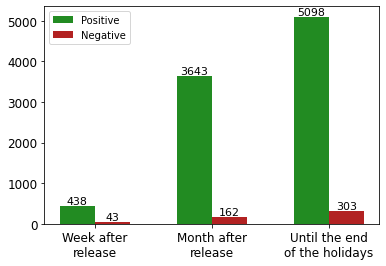

In [104]:
fig, ax = plt.subplots()

plt.bar(np.arange(len(next_generation_positives))-width/2, next_generation_positives, width, label='Positive', color='forestgreen')
plt.bar(np.arange(len(next_generation_negatives))+width/2, next_generation_negatives, width, label='Negative', color='firebrick')
plt.xticks(range(len(holiday_categories)-1,-1,-1), holiday_categories, rotation='horizontal', size=12)
plt.yticks(size=12)

for index in range(len(holiday_categories)):
    ax.text(np.arange(len(next_generation_positives))[index]-width/2, next_generation_positives[index], next_generation_positives[index], ha='center', va='bottom', size=11)
    ax.text(np.arange(len(next_generation_negatives))[index]+width/2, next_generation_negatives[index], next_generation_negatives[index], ha='center', va='bottom', size=11)

plt.legend()

plt.show()

The ratio between positive and negative reviews tends to converge after a bit of time as seen in previous patches, but this time it diverged! Starting off at about a 10-to-1 rate after a week, that ratio jumped to about a 17-to-1 rate after the new year. So how did it happen?

While the addition of VR was nice, the poor performances from VR affected the gaming experience and disappointed many players. <b>Hello Games</b> spent quite a bit of time to hammer out all the issues, and [what came out of it was not just significant VR and graphics updates but also stellar gameplay and further quality-of-life improvements](https://www.nomanssky.com/next-generation-update/).

#### How did the Next Generation reviews from the most prolific reviewers break down?

In [105]:
next_gen_prolific_reviews_over_250 = next_gen_patch.loc[(next_gen_patch['Total Reviews'] > 250)]
next_gen_prolific_reviews_over_250_positive = next_gen_prolific_reviews_over_250.loc[(next_gen_patch['Recommended?'] == True)].count()[0]
next_gen_prolific_reviews_over_250_negative = next_gen_prolific_reviews_over_250.loc[(next_gen_patch['Recommended?'] == False)].count()[0]

print(f'{next_gen_prolific_reviews_over_250_positive} positive reviews.')
print(f'{next_gen_prolific_reviews_over_250_negative} negative reviews.')
print(f'{round(100*next_gen_prolific_reviews_over_250_positive/next_gen_prolific_reviews_over_250.count()[0], 2)}% rating.')

14 positive reviews.
8 negative reviews.
63.64% rating.


#### How did the Next Generation reviews from slightly less prolific reviewers break down?

In [106]:
next_gen_prolific_reviews_between_100_and_250 = next_gen_patch.loc[(next_gen_patch['Total Reviews'] > 100) & (next_gen_patch['Total Reviews'] <= 250)]
next_gen_prolific_reviews_between_100_and_250_positive = next_gen_prolific_reviews_between_100_and_250.loc[(next_gen_prolific_reviews_between_100_and_250['Recommended?'] == True)].count()[0]
next_gen_prolific_reviews_between_100_and_250_negative = next_gen_prolific_reviews_between_100_and_250.loc[(next_gen_prolific_reviews_between_100_and_250['Recommended?'] == False)].count()[0]

print(f'{next_gen_prolific_reviews_between_100_and_250_positive} positive reviews.')
print(f'{next_gen_prolific_reviews_between_100_and_250_negative} negative reviews.')
print(f'{round(100*next_gen_prolific_reviews_between_100_and_250_positive/next_gen_prolific_reviews_between_100_and_250.count()[0], 2)}% rating.')

123 positive reviews.
24 negative reviews.
83.67% rating.


#### How did the Next Generation reviews from Steam and non-Steam purchases break down?

In [107]:
next_gen_steam_purchase_positive = next_gen_positives.loc[(next_gen_positives['Steam Purchase'] == True)].count()[0]
next_gen_steam_purchase_negative = next_gen_negatives.loc[(next_gen_negatives['Steam Purchase'] == True)].count()[0]
next_gen_nonsteam_purchase_positive = next_gen_positives.loc[(next_gen_positives['Steam Purchase'] == False)].count()[0]
next_gen_nonsteam_purchase_negative = next_gen_negatives.loc[(next_gen_negatives['Steam Purchase'] == False)].count()[0]

next_gen_steam_nonsteam_breakdown = [next_gen_steam_purchase_positive, next_gen_nonsteam_purchase_positive, next_gen_steam_purchase_negative, next_gen_nonsteam_purchase_negative]

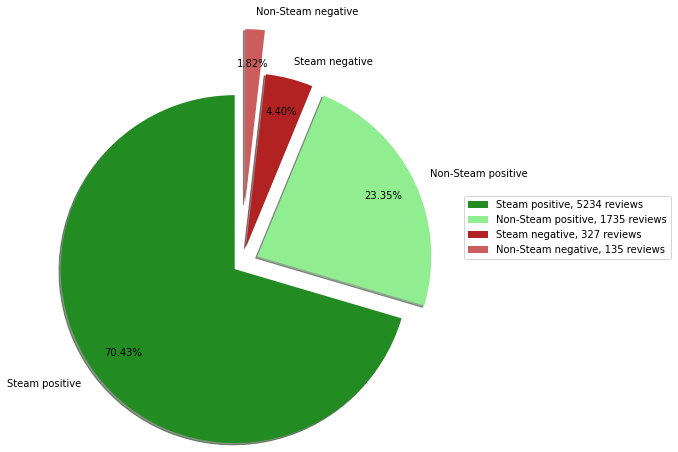

In [108]:
explode = (0.1, 0.2, 0.2, 0.7)

plt.pie(next_gen_steam_nonsteam_breakdown, labels=steam_review_categories, explode=explode, autopct='%1.2f%%', colors=posi_nega_color_set, shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels=['%s, %1.0f reviews' % (l, s) for l, s in zip(steam_review_categories, next_gen_steam_nonsteam_breakdown)], bbox_to_anchor=(1.5, 0.5), loc='lower left')

plt.show()

#### How much did the Next Generation reviews correlate with staying power?

In [109]:
next_gen_positive_postreview_time = next_gen_positives['Post Review Playing Time']
next_gen_negative_postreview_time = next_gen_negatives['Post Review Playing Time']

print(f'On average, reviewers who rated the game positively played an extra {round(next_gen_positive_postreview_time.mean())} hours after their review.')
print(f'On average, reviewers who rated the game negatively played an extra {round(next_gen_negative_postreview_time.mean())} hours after their review.')

On average, reviewers who rated the game positively played an extra 9018 hours after their review.
On average, reviewers who rated the game negatively played an extra 3084 hours after their review.


In [110]:
next_gen_positive_post_review_time_up_to_half_week = next_gen_positives.loc[(next_gen_positives['Post Review Playing Time'] < 5040)].count()[0]
next_gen_positive_post_review_time_up_to_week = next_gen_positives.loc[(next_gen_positives['Post Review Playing Time'] >= 5040) & (next_gen_positives['Post Review Playing Time'] < 10080)].count()[0]
next_gen_positive_post_review_time_week_more = next_gen_positives.loc[(next_gen_positives['Post Review Playing Time'] >= 10080)].count()[0]

next_gen_negative_post_review_time_up_to_half_week = next_gen_negatives.loc[(next_gen_negatives['Post Review Playing Time'] < 5040)].count()[0]
next_gen_negative_post_review_time_up_to_week = next_gen_negatives.loc[(next_gen_negatives['Post Review Playing Time'] >= 5040) & (next_gen_negatives['Post Review Playing Time'] < 10080)].count()[0]
next_gen_negative_post_review_time_week_more = next_gen_negatives.loc[(next_gen_negatives['Post Review Playing Time'] >= 10080)].count()[0]

next_gen_positive_data = np.array([100*next_gen_positive_post_review_time_up_to_half_week/(next_gen_positive_post_review_time_up_to_half_week+next_gen_positive_post_review_time_up_to_week+next_gen_positive_post_review_time_week_more),
                                   100*next_gen_positive_post_review_time_up_to_week/(next_gen_positive_post_review_time_up_to_half_week+next_gen_positive_post_review_time_up_to_week+next_gen_positive_post_review_time_week_more),
                                   100*next_gen_positive_post_review_time_week_more/(next_gen_positive_post_review_time_up_to_half_week+next_gen_positive_post_review_time_up_to_week+next_gen_positive_post_review_time_week_more)])
next_gen_negative_data = np.array([100*next_gen_negative_post_review_time_up_to_half_week/(next_gen_negative_post_review_time_up_to_half_week+next_gen_negative_post_review_time_up_to_week+next_gen_negative_post_review_time_week_more),
                                   100*next_gen_negative_post_review_time_up_to_week/(next_gen_negative_post_review_time_up_to_half_week+next_gen_negative_post_review_time_up_to_week+next_gen_negative_post_review_time_week_more),
                                   100*next_gen_negative_post_review_time_week_more/(next_gen_negative_post_review_time_up_to_half_week+next_gen_negative_post_review_time_up_to_week+next_gen_negative_post_review_time_week_more)])

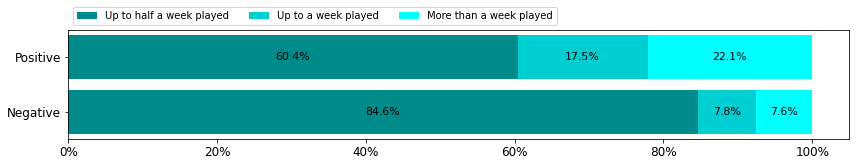

In [111]:
data = np.array(list([next_gen_positive_data, next_gen_negative_data]))
data_cum = data.cumsum(axis=1)

fig, ax = plt.subplots(figsize=(14, 2))
ax.invert_yaxis()
plt.xticks(size=12)
plt.yticks(size=12)

for i, (colname, color) in enumerate(zip(post_review_timings, time_color_set)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = ax.barh(keys, widths, left=starts, label=colname, color=color)

    ax.bar_label(rects, fmt='%.1f%%', label_type='center', color='black', size=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.legend(post_review_timings, ncols=len(post_review_timings), bbox_to_anchor=(0, 1), loc='lower left')

plt.show()

### Part III: Path To Very Positive Overall.

#### Which No Man's Sky review garnered the most reactions?

In [112]:
post_positive_upvoted_count = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] == max(mnsdata_post_positive['Reactions']))]['Reactions'].values[0]
post_positive_upvoted_review = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] == max(mnsdata_post_positive['Reactions']))]['Reviews'].values[0]
post_positive_upvoted_funny = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] == max(mnsdata_post_positive['Reactions']))]['Funny'].values[0]
post_positive_upvoted_upvote = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] == max(mnsdata_post_positive['Reactions']))]['Up'].values[0]
post_positive_upvoted_date = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] == max(mnsdata_post_positive['Reactions']))]['Date'].values[0]

print(f'{post_positive_upvoted_review}')
print(f'---\nSubmitted on {post_positive_upvoted_date}, this review garnered {post_positive_upvoted_count} reactions ({post_positive_upvoted_funny} laughs and {post_positive_upvoted_upvote} upvotes).')

open game wow nice title
cuts to white screen
confusion "what now"
crash 

reopen game
nice title again
white again
crash

repeat lots to be able to write review 
ps will change if this game is ever fixed

(i never picked this game back up but from all the comments i can assume its fixed and a good game now no need to spam the comments anymore)
---
Submitted on 2023-08-05, this review garnered 4421 reactions (1177 laughs and 3244 upvotes).


#### How did the other reviews with over 2,000 reactions feel about the game?

In [113]:
mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] > 2000)].sort_values(by='Reactions', ascending=False)

,id,Funny,Up,Total Reviews,Review Playing Time,Total Playing Time,Post Review Playing Time,Reactions,Reviews,Recommended?,Steam Purchase,Date,Anniversary
223866,24846690,1177,3244,5,10,10,0,4421,open game wow nice title\ncuts to white screen...,False,True,2023-08-05,7
88630,113592745,67,3922,29,15827,29145,13318,3989,This is Hello Games.\n\nHello Games acknowledg...,True,True,2022-05-13,6
66405,139575704,214,3346,2,6010,8750,2740,3560,A week ago I was diagnosed with a terminal ill...,True,False,2023-06-04,7
40690,172283888,85,2928,5,314,664,350,3013,I can't believe they kept working on it after ...,True,True,2024-08-16,9
102992,98550874,32,2943,32,837,8882,8045,2975,Two things this game will be remembered for:\n...,True,False,2021-09-09,6
82760,118188008,104,2749,934,6983,6983,0,2853,"No Man’s Sky is like a guy who owes you $1,000...",True,False,2022-07-04,6
48463,168363610,72,2734,7,11141,14911,3770,2806,one of the last not greedy devs,True,False,2024-06-27,8
88959,112836324,42,2589,61,6577,6577,0,2631,"AFTER ALL THIS TIME, THEY STILL GIVE GAME UPDA...",True,True,2022-03-26,6
69715,134320927,77,2512,115,6629,111251,104622,2589,\nI can't believe they kept working on it afte...,True,False,2023-03-08,7
47751,170117655,509,1934,39,504,1038,534,2443,EA see Sean in their nightmares.,True,True,2024-07-17,8


Besides that one blemish, every other review was positive and expressed shock and surprise that <b>Hello Games</b> was still working on the game and giving more and more updates to keep it amazing.

<i>"EA see Sean in their nightmares."</i> is hilarious.

#### How did the reviews break down by reactions?

In [114]:
post_positive_reactions_over_100 = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] > 100)]
post_positive_reactions_between_51_and_100 = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] > 50) & (mnsdata_post_positive['Reactions'] <= 100)]
post_positive_reactions_between_26_and_50 = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] > 25) & (mnsdata_post_positive['Reactions'] <= 50)]
post_positive_reactions_between_11_and_25 = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] > 10) & (mnsdata_post_positive['Reactions'] <= 25)]
post_positive_reactions_between_1_and_10 = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] >= 1) & (mnsdata_post_positive['Reactions'] <= 10)]
post_positive_reactions_at_0 = mnsdata_post_positive.loc[(mnsdata_post_positive['Reactions'] == 0)]

post_positive_reactions_by_category = [
    post_positive_reactions_over_100.count()[0],
    post_positive_reactions_between_51_and_100.count()[0],
    post_positive_reactions_between_26_and_50.count()[0],
    post_positive_reactions_between_11_and_25.count()[0],
    post_positive_reactions_between_1_and_10.count()[0],
    post_positive_reactions_at_0.count()[0]
]

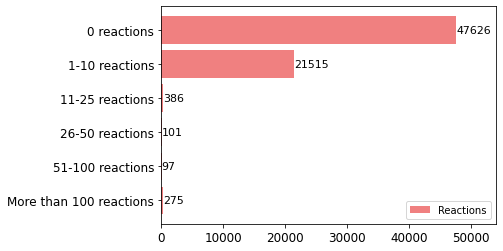

In [115]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, post_positive_reactions_by_category, label='Reactions', color='lightcoral')
plt.xticks(size=12)
plt.xlim(0, 54000)
plt.yticks(rotation='horizontal', size=12)

for index in range(len(reactions_categories)):
    ax.text(post_positive_reactions_by_category[index], reactions_categories[index], post_positive_reactions_by_category[index], rotation='horizontal', va='center', size=11)

plt.legend(loc='lower right')

plt.show()

In [116]:
post_positive_reactions_over_100_positive = post_positive_reactions_over_100.loc[(mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_reactions_over_100_negative = post_positive_reactions_over_100.loc[(mnsdata_post_positive['Recommended?'] == False)].count()[0]
post_positive_reactions_between_51_and_100_positive = post_positive_reactions_between_51_and_100.loc[(mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_reactions_between_51_and_100_negative = post_positive_reactions_between_51_and_100.loc[(mnsdata_post_positive['Recommended?'] == False)].count()[0]
post_positive_reactions_between_26_and_50_positive = post_positive_reactions_between_26_and_50.loc[(mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_reactions_between_26_and_50_negative = post_positive_reactions_between_26_and_50.loc[(mnsdata_post_positive['Recommended?'] == False)].count()[0]
post_positive_reactions_between_11_and_25_positive = post_positive_reactions_between_11_and_25.loc[(mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_reactions_between_11_and_25_negative = post_positive_reactions_between_11_and_25.loc[(mnsdata_post_positive['Recommended?'] == False)].count()[0]
post_positive_reactions_between_1_and_10_positive = post_positive_reactions_between_1_and_10.loc[(mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_reactions_between_1_and_10_negative = post_positive_reactions_between_1_and_10.loc[(mnsdata_post_positive['Recommended?'] == False)].count()[0]
post_positive_reactions_at_0_positive = post_positive_reactions_at_0.loc[(mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_reactions_at_0_negative = post_positive_reactions_at_0.loc[(mnsdata_post_positive['Recommended?'] == False)].count()[0]

post_positive_reactions_by_category_positive = [
    post_positive_reactions_over_100_positive,
    post_positive_reactions_between_51_and_100_positive,
    post_positive_reactions_between_26_and_50_positive,
    post_positive_reactions_between_11_and_25_positive,
    post_positive_reactions_between_1_and_10_positive,
    post_positive_reactions_at_0_positive
]
post_positive_reactions_by_category_negative = [
    post_positive_reactions_over_100_negative,
    post_positive_reactions_between_51_and_100_negative,
    post_positive_reactions_between_26_and_50_negative,
    post_positive_reactions_between_11_and_25_negative,
    post_positive_reactions_between_1_and_10_negative,
    post_positive_reactions_at_0_negative
]

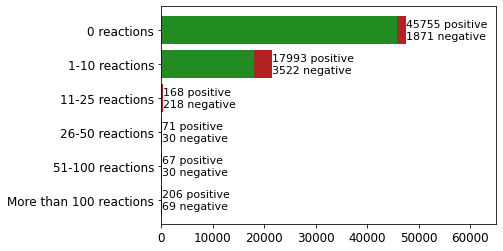

In [117]:
fig, ax = plt.subplots()

plt.barh(reactions_categories, post_positive_reactions_by_category_positive, color='forestgreen')
plt.barh(reactions_categories, post_positive_reactions_by_category_negative, left=post_positive_reactions_by_category_positive, color='firebrick')
plt.xticks(rotation='horizontal', size=12)
plt.xlim(0, 65000)
plt.yticks(size=12)

for index in range(len(reactions_categories)):
    ax.text(post_positive_reactions_by_category_positive[index]+post_positive_reactions_by_category_negative[index], reactions_categories[index], f'{post_positive_reactions_by_category_positive[index]} positive\n{post_positive_reactions_by_category_negative[index]} negative', ha='left', va='center', size=11)

plt.show()

#### How did the reviews from the most prolific reviewers break down?

In [118]:
post_positive_prolific_reviews_over_1000 = mnsdata_post_positive.loc[(mnsdata_post_positive['Total Reviews'] > 1000)]
post_positive_prolific_reviews_over_1000_positive = post_positive_prolific_reviews_over_1000.loc[(mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_prolific_reviews_over_1000_negative = post_positive_prolific_reviews_over_1000.loc[(mnsdata_post_positive['Recommended?'] == False)].count()[0]

print(f'{post_positive_prolific_reviews_over_1000_positive} positive reviews.')
print(f'{post_positive_prolific_reviews_over_1000_negative} negative reviews.')
print(f'{round(100*post_positive_prolific_reviews_over_1000_positive/post_positive_prolific_reviews_over_1000.count()[0], 2)}% rating.')

15 positive reviews.
4 negative reviews.
78.95% rating.


#### How did the reviews from slightly less prolific reviewers break down?

In [119]:
post_positive_prolific_reviews_between_100_and_1000 = mnsdata_post_positive.loc[(mnsdata_post_positive['Total Reviews'] > 100) & (mnsdata_post_positive['Total Reviews'] <= 1000)]
post_positive_prolific_reviews_between_100_and_1000_positive = post_positive_prolific_reviews_between_100_and_1000.loc[(mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_prolific_reviews_between_100_and_1000_negative = post_positive_prolific_reviews_between_100_and_1000.loc[(mnsdata_post_positive['Recommended?'] == False)].count()[0]

print(f'{post_positive_prolific_reviews_between_100_and_1000_positive} positive reviews.')
print(f'{post_positive_prolific_reviews_between_100_and_1000_negative} negative reviews.')
print(f'{round(100*post_positive_prolific_reviews_between_100_and_1000_positive/post_positive_prolific_reviews_between_100_and_1000.count()[0], 2)}% rating.')

1673 positive reviews.
402 negative reviews.
80.63% rating.


#### How did the reviews from Steam and non-Steam purchases break down?

In [120]:
post_positive_steam_purchase_positive = mnsdata_post_positive.loc[(mnsdata_post_positive['Steam Purchase'] == True) & (mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_steam_purchase_negative = mnsdata_post_positive.loc[(mnsdata_post_positive['Steam Purchase'] == True) & (mnsdata_post_positive['Recommended?'] == False)].count()[0]
post_positive_nonsteam_purchase_positive = mnsdata_post_positive.loc[(mnsdata_post_positive['Steam Purchase'] == False) & (mnsdata_post_positive['Recommended?'] == True)].count()[0]
post_positive_nonsteam_purchase_negative = mnsdata_post_positive.loc[(mnsdata_post_positive['Steam Purchase'] == False) & (mnsdata_post_positive['Recommended?'] == False)].count()[0]

post_positive_steam_nonsteam_breakdown = [post_positive_steam_purchase_positive, post_positive_nonsteam_purchase_positive, post_positive_steam_purchase_negative, post_positive_nonsteam_purchase_negative]

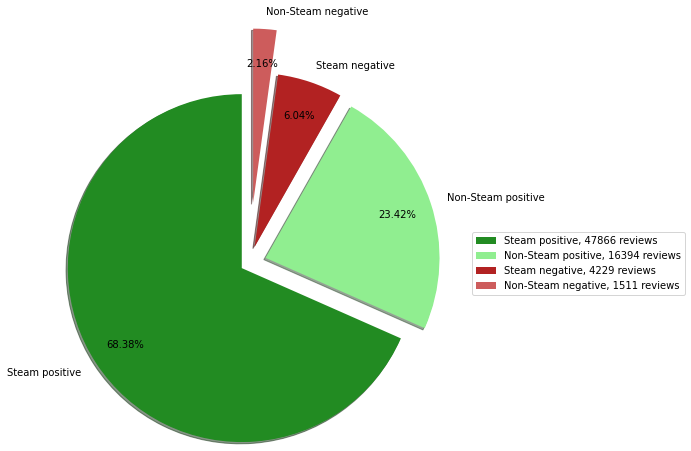

In [121]:
explode = (0.1, 0.2, 0.2, 0.7)

plt.pie(post_positive_steam_nonsteam_breakdown, labels=steam_review_categories, explode=explode, autopct='%1.2f%%', colors=posi_nega_color_set, shadow=True, startangle=90, radius=2, pctdistance=0.8, labeldistance=1.1)
plt.legend(labels=['%s, %1.0f reviews' % (l, s) for l, s in zip(steam_review_categories, post_positive_steam_nonsteam_breakdown)], bbox_to_anchor=(1.5, 0.5), loc='center left')

plt.show()

#### How much did the reviews correlate with staying power?

In [122]:
post_positive_postreview_time = mnsdata_post_positive.loc[(mnsdata_post_positive['Recommended?'] == True)]['Post Review Playing Time']
post_negative_postreview_time = mnsdata_post_positive.loc[(mnsdata_post_positive['Recommended?'] == False)]['Post Review Playing Time']

print(f'On average, reviewers who rated the game positively played an extra {round(post_positive_postreview_time.mean())} hours after their review.')
print(f'On average, reviewers who rated the game negatively played an extra {round(post_negative_postreview_time.mean())} hours after their review.')

On average, reviewers who rated the game positively played an extra 7453 hours after their review.
On average, reviewers who rated the game negatively played an extra 3169 hours after their review.


In [123]:
post_positive_post_review_time_up_to_half_week = mnsdata_post_positive.loc[(mnsdata_post_positive['Recommended?'] == True) & (mnsdata_post_positive['Post Review Playing Time'] <= 5040)].count()[0]
post_positive_post_review_time_up_to_week = mnsdata_post_positive.loc[(mnsdata_post_positive['Recommended?'] == True) & (mnsdata_post_positive['Post Review Playing Time'] >= 5041) & (mnsdata_post_positive['Post Review Playing Time'] <= 10080)].count()[0]
post_positive_post_review_time_week_more = mnsdata_post_positive.loc[(mnsdata_post_positive['Recommended?'] == True) & (mnsdata_post_positive['Post Review Playing Time'] > 10080)].count()[0]

post_negative_post_review_time_up_to_half_week = mnsdata_post_positive.loc[(mnsdata_post_positive['Recommended?'] == False) & (mnsdata_post_positive['Post Review Playing Time'] <= 5040)].count()[0]
post_negative_post_review_time_up_to_week = mnsdata_post_positive.loc[(mnsdata_post_positive['Recommended?'] == False) & (mnsdata_post_positive['Post Review Playing Time'] >= 5041) & (mnsdata_post_positive['Post Review Playing Time'] <= 10080)].count()[0]
post_negative_post_review_time_week_more = mnsdata_post_positive.loc[(mnsdata_post_positive['Recommended?'] == False) & (mnsdata_post_positive['Post Review Playing Time'] > 10080)].count()[0]

post_positive_data = np.array([100*post_positive_post_review_time_up_to_half_week/(post_positive_post_review_time_up_to_half_week+post_positive_post_review_time_up_to_week+post_positive_post_review_time_week_more),
                               100*post_positive_post_review_time_up_to_week/(post_positive_post_review_time_up_to_half_week+post_positive_post_review_time_up_to_week+post_positive_post_review_time_week_more),
                               100*post_positive_post_review_time_week_more/(post_positive_post_review_time_up_to_half_week+post_positive_post_review_time_up_to_week+post_positive_post_review_time_week_more)])
post_negative_data = np.array([100*post_negative_post_review_time_up_to_half_week/(post_negative_post_review_time_up_to_half_week+post_negative_post_review_time_up_to_week+post_negative_post_review_time_week_more),
                               100*post_negative_post_review_time_up_to_week/(post_negative_post_review_time_up_to_half_week+post_negative_post_review_time_up_to_week+post_negative_post_review_time_week_more),
                               100*post_negative_post_review_time_week_more/(post_negative_post_review_time_up_to_half_week+post_negative_post_review_time_up_to_week+post_negative_post_review_time_week_more)])

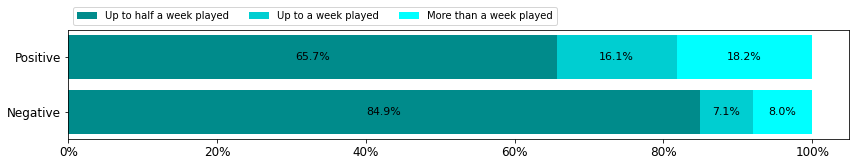

In [124]:
data = np.array(list([post_positive_data, post_negative_data]))
data_cum = data.cumsum(axis=1)

fig, ax = plt.subplots(figsize=(14, 2))
ax.invert_yaxis()
plt.xticks(size=12)
plt.yticks(size=12)

for i, (colname, color) in enumerate(zip(post_review_timings, time_color_set)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = ax.barh(keys, widths, left=starts, label=colname, color=color)

    ax.bar_label(rects, fmt='%.1f%%', label_type='center', color='black', size=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.legend(post_review_timings, ncols=len(post_review_timings), bbox_to_anchor=(0, 1), loc='lower left')

plt.show()

### Part IV: Journey Through The Years.

#### How were the ratings broken down by anniversaries?

In [125]:
anniversary_1_positives = mnsdata.loc[(mnsdata['Anniversary'] == 1) & (mnsdata['Recommended?'] == True)]
anniversary_1_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 1) & (mnsdata['Recommended?'] == False)]
anniversary_2_positives = mnsdata.loc[(mnsdata['Anniversary'] == 2) & (mnsdata['Recommended?'] == True)]
anniversary_2_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 2) & (mnsdata['Recommended?'] == False)]
anniversary_3_positives = mnsdata.loc[(mnsdata['Anniversary'] == 3) & (mnsdata['Recommended?'] == True)]
anniversary_3_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 3) & (mnsdata['Recommended?'] == False)]
anniversary_4_positives = mnsdata.loc[(mnsdata['Anniversary'] == 4) & (mnsdata['Recommended?'] == True)]
anniversary_4_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 4) & (mnsdata['Recommended?'] == False)]
anniversary_5_positives = mnsdata.loc[(mnsdata['Anniversary'] == 5) & (mnsdata['Recommended?'] == True)]
anniversary_5_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 5) & (mnsdata['Recommended?'] == False)]
anniversary_6_positives = mnsdata.loc[(mnsdata['Anniversary'] == 6) & (mnsdata['Recommended?'] == True)]
anniversary_6_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 6) & (mnsdata['Recommended?'] == False)]
anniversary_7_positives = mnsdata.loc[(mnsdata['Anniversary'] == 7) & (mnsdata['Recommended?'] == True)]
anniversary_7_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 7) & (mnsdata['Recommended?'] == False)]
anniversary_8_positives = mnsdata.loc[(mnsdata['Anniversary'] == 8) & (mnsdata['Recommended?'] == True)]
anniversary_8_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 8) & (mnsdata['Recommended?'] == False)]
anniversary_9_positives = mnsdata.loc[(mnsdata['Anniversary'] == 9) & (mnsdata['Recommended?'] == True)]
anniversary_9_negatives = mnsdata.loc[(mnsdata['Anniversary'] == 9) & (mnsdata['Recommended?'] == False)]

anniversary_review_totals = [
    anniversary_1_positives.count()[0]+anniversary_1_negatives.count()[0],
    anniversary_2_positives.count()[0]+anniversary_2_negatives.count()[0],
    anniversary_3_positives.count()[0]+anniversary_3_negatives.count()[0],
    anniversary_4_positives.count()[0]+anniversary_4_negatives.count()[0],
    anniversary_5_positives.count()[0]+anniversary_5_negatives.count()[0],
    anniversary_6_positives.count()[0]+anniversary_6_negatives.count()[0],
    anniversary_7_positives.count()[0]+anniversary_7_negatives.count()[0],
    anniversary_8_positives.count()[0]+anniversary_8_negatives.count()[0],
    anniversary_9_positives.count()[0]+anniversary_9_negatives.count()[0]
]
anniversary_positive_pct = [
    anniversary_1_positives.count()[0]/(anniversary_review_totals[0]),
    anniversary_2_positives.count()[0]/(anniversary_review_totals[1]),
    anniversary_3_positives.count()[0]/(anniversary_review_totals[2]),
    anniversary_4_positives.count()[0]/(anniversary_review_totals[3]),
    anniversary_5_positives.count()[0]/(anniversary_review_totals[4]),
    anniversary_6_positives.count()[0]/(anniversary_review_totals[5]),
    anniversary_7_positives.count()[0]/(anniversary_review_totals[6]),
    anniversary_8_positives.count()[0]/(anniversary_review_totals[7]),
    anniversary_9_positives.count()[0]/(anniversary_review_totals[8])
]

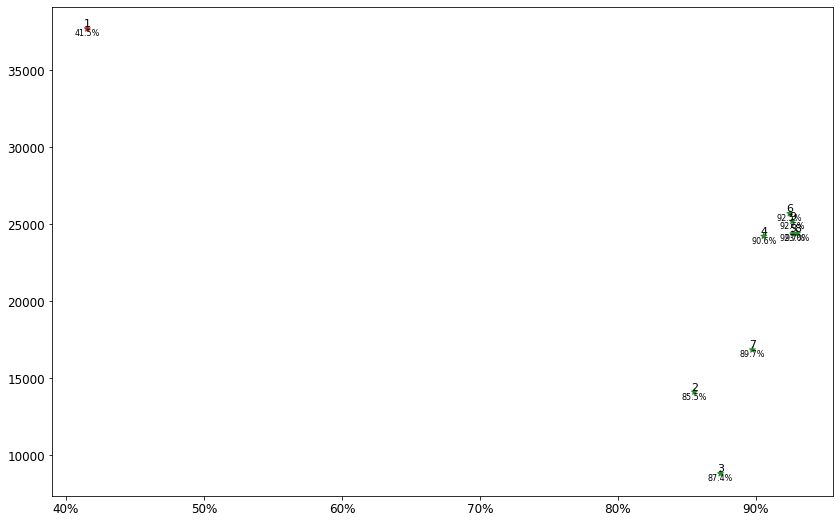

In [126]:
anniversaries = ['1', '2', '3', '4', '5', '6', '7', '8', '9']

fig, ax = plt.subplots(figsize=(14, 9))

plt.scatter(anniversary_positive_pct, anniversary_review_totals, c=['firebrick' if anniversary_positive_pct[i] < 0.7 else 'forestgreen' for i in range(len(anniversary_positive_pct))], marker='*')
plt.xticks(size=12)
plt.yticks(size=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

for index in range(len(anniversaries)):
    plt.text(anniversary_positive_pct[index], anniversary_review_totals[index], anniversaries[index], ha='center', va='bottom', size=11)
    plt.text(anniversary_positive_pct[index], anniversary_review_totals[index], f'{round(100*anniversary_positive_pct[index], 1)}%', ha='center', va='top', size=8)

plt.show()

It is absolutely unsurprising to see how much the game struggled in its 1st year, but after that there were not too many surprises. By the time <b>No Man's Sky</b> hit its 5th year mark, the game was <i>easily</i> sailing past 90% overall with the exception of the 7th year.

#### How did its cumulative rating change after each year?

In [127]:
anniversary_1_total_agg = anniversary_review_totals[0]
anniversary_2_agg = (anniversary_1_positives.count()[0] + anniversary_2_positives.count()[0])
anniversary_2_total_agg = (anniversary_review_totals[1] + anniversary_1_total_agg)
anniversary_3_agg = (anniversary_3_positives.count()[0] + anniversary_2_agg)
anniversary_3_total_agg = (anniversary_review_totals[2] + anniversary_2_total_agg)
anniversary_4_agg = (anniversary_4_positives.count()[0] + anniversary_3_agg)
anniversary_4_total_agg = (anniversary_review_totals[3] + anniversary_3_total_agg)
anniversary_5_agg = (anniversary_5_positives.count()[0] + anniversary_4_agg)
anniversary_5_total_agg = (anniversary_review_totals[4] + anniversary_4_total_agg)
anniversary_6_agg = (anniversary_6_positives.count()[0] + anniversary_5_agg)
anniversary_6_total_agg = (anniversary_review_totals[5] + anniversary_5_total_agg)
anniversary_7_agg = (anniversary_6_positives.count()[0] + anniversary_6_agg)
anniversary_7_total_agg = (anniversary_review_totals[6] + anniversary_6_total_agg)
anniversary_8_agg = (anniversary_8_positives.count()[0] + anniversary_7_agg)
anniversary_8_total_agg = (anniversary_review_totals[7] + anniversary_7_total_agg)
anniversary_9_agg = (anniversary_9_positives.count()[0] + anniversary_8_agg)
anniversary_9_total_agg = (anniversary_review_totals[8] + anniversary_8_total_agg)

anniversary_pct_agg = [
    anniversary_1_positives.count()[0]/anniversary_1_total_agg,
    anniversary_2_agg/anniversary_2_total_agg,
    anniversary_3_agg/anniversary_3_total_agg,
    anniversary_4_agg/anniversary_4_total_agg,
    anniversary_5_agg/anniversary_5_total_agg,
    anniversary_6_agg/anniversary_6_total_agg,
    anniversary_7_agg/anniversary_7_total_agg,
    anniversary_8_agg/anniversary_8_total_agg,
    anniversary_9_agg/anniversary_9_total_agg
]

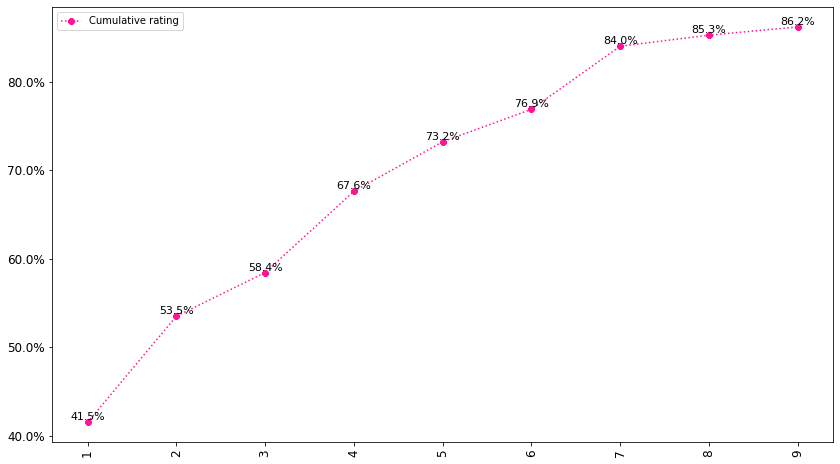

In [128]:
fig, ax = plt.subplots(figsize=(14, 8))

plt.plot(anniversaries, anniversary_pct_agg, ':', label='Cumulative rating', color='deeppink', marker='8')
plt.xticks(rotation='vertical', size=12)
plt.yticks(size=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for index in range(len(anniversaries)):
    ax.text(anniversaries[index], anniversary_pct_agg[index], f'{round(anniversary_pct_agg[index]*100, 1)}%', ha='center', va='bottom', size=11)

plt.legend()

plt.show()

## Dataframe splitting

The dataframe will now be re-exported as different patch files for the following reasons:
- GitHub's upload limit prevents uploading of files over 100mb.
- Better control and utilisation during the next stage of this project: Natural language processing.

In [129]:
foundation_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2016-11-26') & (mnsdata_pre_positive['Date'] <= '2017-03-07')]
pathfinder_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2017-03-08') & (mnsdata_pre_positive['Date'] <= '2017-08-10')]
abyss_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-10-29') & (mnsdata_pre_positive['Date'] <= '2018-11-21')]
visions_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2018-11-22') & (mnsdata_pre_positive['Date'] <= '2019-08-13')]
synthesis_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2019-11-28') & (mnsdata_pre_positive['Date'] <= '2020-02-17')]
living_ship_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-02-18') & (mnsdata_pre_positive['Date'] <= '2020-04-06')]
exo_mech_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-04-07') & (mnsdata_pre_positive['Date'] <= '2020-06-10')]
crossplay_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-06-11') & (mnsdata_pre_positive['Date'] <= '2020-07-15')]
desolation_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-07-16') & (mnsdata_pre_positive['Date'] <= '2020-09-22')]
origins_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2020-09-23') & (mnsdata_pre_positive['Date'] <= '2020-11-09')]
companions_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-02-17') & (mnsdata_pre_positive['Date'] <= '2021-03-30')]
expeditions_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-03-31') & (mnsdata_pre_positive['Date'] <= '2021-06-01')]
prisms_patch = mnsdata_pre_positive.loc[(mnsdata_pre_positive['Date'] >= '2021-06-02') & (mnsdata_pre_positive['Date'] <= '2021-08-30')]

In [130]:
nms_initial = initial_patch
nms_initial.to_json("./mns-data/nms_initial.json")

nms_foundation = foundation_patch
nms_foundation.to_json("./mns-data/nms_foundation.json")

nms_pathfinder = pathfinder_patch
nms_pathfinder.to_json("./mns-data/nms_pathfinder.json")

nms_atlas_rises = ar_patch
nms_atlas_rises.to_json("./mns-data/nms_atlas_rises.json")

nms_next = next_patch
nms_next.to_json("./mns-data/nms_next.json")

nms_abyss = abyss_patch
nms_abyss.to_json("./mns-data/nms_abyss.json")

nms_visions = visions_patch
nms_visions.to_json("./mns-data/nms_visions.json")

nms_beyond = beyond_patch
nms_beyond.to_json("./mns-data/nms_beyond.json")

nms_synthesis = synthesis_patch
nms_synthesis.to_json("./mns-data/nms_synthesis.json")

nms_living_ship = living_ship_patch
nms_living_ship.to_json("./mns-data/nms_living_ship.json")

nms_exo_mech = exo_mech_patch
nms_exo_mech.to_json("./mns-data/nms_exo_mech.json")

nms_crossplay = crossplay_patch
nms_crossplay.to_json("./mns-data/nms_crossplay.json")

nms_desolation = desolation_patch
nms_desolation.to_json("./mns-data/nms_desolation.json")

nms_origins = origins_patch
nms_origins.to_json("./mns-data/nms_origins.json")

nms_next_generations = next_gen_patch
nms_next_generations.to_json("./mns-data/nms_next_generations.json")

nms_companions = companions_patch
nms_companions.to_json("./mns-data/nms_companions.json")

nms_expeditions = expeditions_patch
nms_expeditions.to_json("./mns-data/nms_expeditions.json")

nms_prisms = prisms_patch
nms_prisms.to_json("./mns-data/nms_prisms.json")

nms_post_positive = mnsdata_post_positive
nms_post_positive.to_json("./mns-data/nms_post_positive.json")

## Credits
Special thanks to <br>
https://www.youtube.com/watch?v=O5BJVO3PDeQ <br>
for the idea.

Positive overall: <br>
https://gamerant.com/no-mans-sky-steam-positive-reviews-overall-rating/ <br>
https://x.com/NoMansSky/status/1434936664279994376

Very positive overall: <br>
https://gamerant.com/no-mans-sky-positive-reviews-steam/ <br>
https://x.com/NoMansSky/status/1861859832187211963